## Imports

In [32]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error
import shap
from statsmodels.tools.tools import add_constant
import optuna
import optuna.visualization as vis
from sklearn.inspection import PartialDependenceDisplay

## Dataset

In [33]:
df = pd.read_csv('CSVs_final/final_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Data columns (total 86 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   date                                                                                1904 non-null   object 
 1   Year                                                                                1904 non-null   int64  
 2   Month                                                                               1904 non-null   int64  
 3   parish                                                                              1904 non-null   object 
 4   price_m2                                                                            1904 non-null   float64
 5   imputed_flag                                                                        1904 non-null

## Data Types

A coluna Densidade_Populacional_2021 continua como object.

In [34]:
# Converter a Densidade Populacional para numérico (substituindo vírgulas por pontos, se for o caso)
if df['Densidade_Populacional_2021'].dtype == 'object':
    df['Densidade_Populacional_2021'] = (
        df['Densidade_Populacional_2021']
        .astype(str)
        .str.replace(',', '.')
        .str.replace(' ', '')
        .astype(float)
    )
    
df['date'] = pd.to_datetime(df['date'])

## Missing Values

A integridade do dataset foi assegurada previamente e as observações imputadas foram mantidas e sinalizadas (imputed_flag) para garantir que o algoritmo não perde volume de dados (sample size) essencial para capturar as dinâmicas de toda a cidade ao longo de quase 10 anos (1904 observações mensais).

## Feature Engineering

### Percentagem de Agregados Unipessoais
A percentagem de agregados unipessoais representa a proporção de alojamentos ocupados por apenas uma pessoa dentro de uma determinada área (por exemplo freguesia ou secção estatística).
Esta variável funciona como proxy de estrutura demográfica e estilo de vida urbano.

Valores elevados normalmente indicam:
- áreas mais centrais
- presença de jovens profissionais ou idosos isolados
- maior mobilidade residencial
- maior presença de habitação pequena (T0/T1)

Colunas a Remover: Número_Agregados_1_Pessoa_2021 até Número_Agregados_9_Mais_Pessoas_2021, Total_Agregados_2021 e Dimensao_Media_Agregados_2021

$$\text{Pct\_Agregados\_Unipessoais} = \frac{\text{Número\_Agregados\_1\_Pessoa\_2021}}{\text{Total\_Agregados\_2021}} \times 100$$

In [35]:
df['Pct_Agregados_Unipessoais'] = (df['Número_Agregados_1_Pessoa_2021'] / df['Total_Agregados_2021']) * 100

### Taxas de Conversão (Reabilitação e Nova Construção)

As taxas de conversão de reabilitação e nova construção medem a proporção da área pedida em processos urbanísticos que efetivamente obtém aprovação. Estas variáveis funcionam como indicadores da eficiência do pipeline de desenvolvimento urbano, captando a capacidade de transformação do tecido urbano e a intensidade efetiva de investimento imobiliário.

$$\text{Taxa\_Conversao\_Reabilitacao} = \frac{\text{Área de Alvarás Reabilitação}}{\text{Área de Pedidos Reabilitação}}$$

$$\text{Taxa\_Conversao\_Nova\_Construcao} = \frac{\text{Área de Alvarás Nova Construção}}{\text{Área de Pedidos Nova Construção}}$$


In [36]:
df['Taxa_Conversao_Reabilitacao'] = (df['Stock_12M_ALV_Reabilitacao_Area'] / (df['Stock_12M_PED_Reabilitacao_Area'].clip(lower=1)))
df['Taxa_Conversao_Nova_Construcao'] = (df['Stock_12M_ALV_Nova_Construcao_Area'] / (df['Stock_12M_PED_Nova_Construcao_Area'].clip(lower=1)))

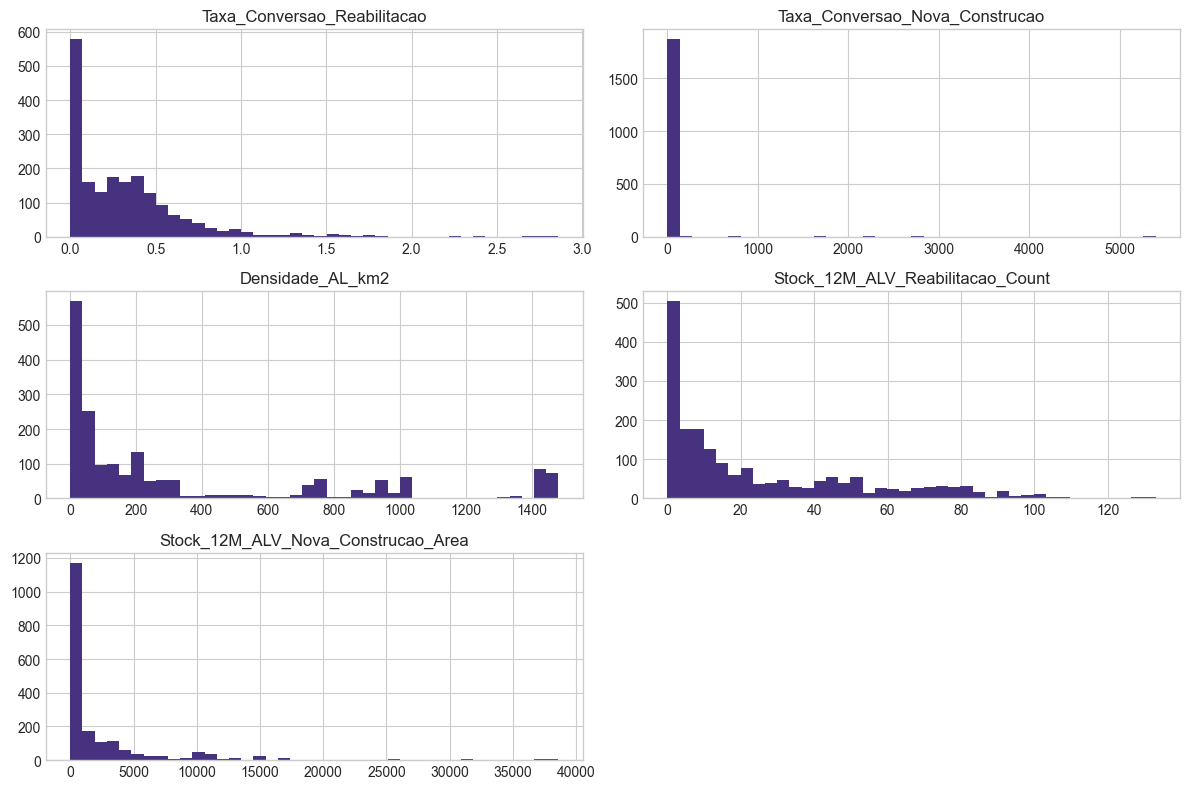

In [37]:
cols = [
    'Taxa_Conversao_Reabilitacao',
    'Taxa_Conversao_Nova_Construcao',
    'Densidade_AL_km2',
    'Stock_12M_ALV_Reabilitacao_Count',
    'Stock_12M_ALV_Nova_Construcao_Area'
]

df[cols].hist(bins=40, figsize=(12,8))
plt.tight_layout()
plt.show()

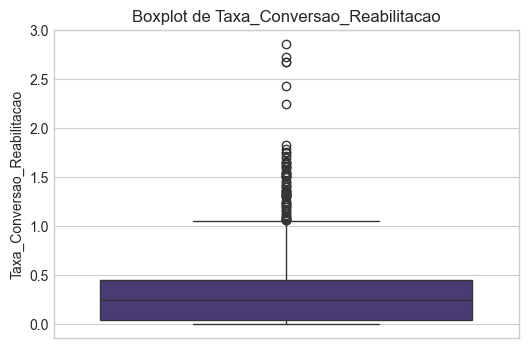

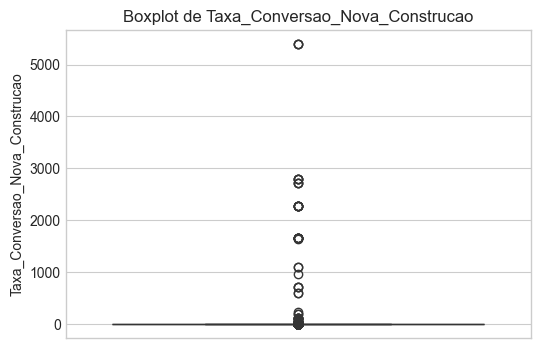

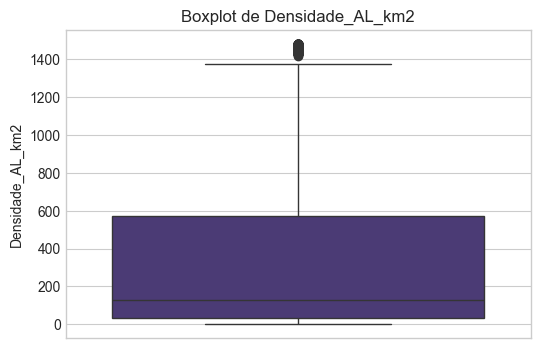

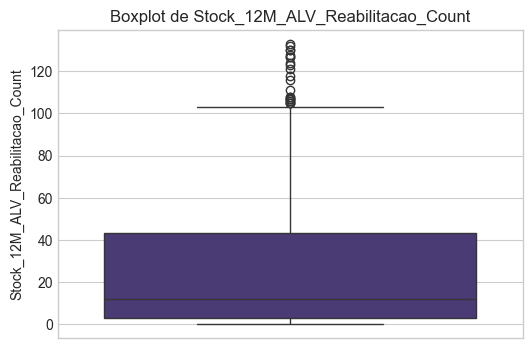

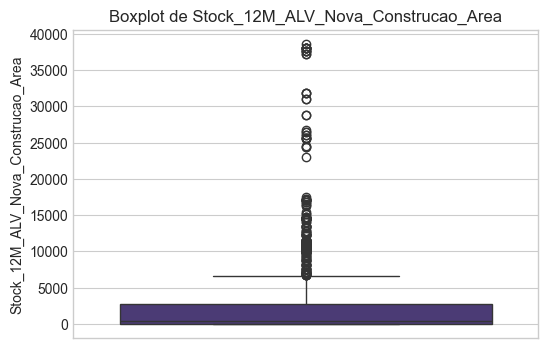

In [38]:
cols = [
    'Taxa_Conversao_Reabilitacao',
    'Taxa_Conversao_Nova_Construcao',
    'Densidade_AL_km2',
    'Stock_12M_ALV_Reabilitacao_Count',
    'Stock_12M_ALV_Nova_Construcao_Area'
]

boxplots = {}
for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

In [39]:
df[cols].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,Taxa_Conversao_Reabilitacao,Taxa_Conversao_Nova_Construcao,Densidade_AL_km2,Stock_12M_ALV_Reabilitacao_Count,Stock_12M_ALV_Nova_Construcao_Area
count,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000
mean,0.315257,40.070484,348.839235,24.988445,2568.033892
std,0.342168,327.533242,455.796744,28.257466,5321.238323
min,0.000000,0.000000,0.997506,0.000000,0.000000
1%,0.000000,0.000000,1.628429,0.000000,0.000000
5%,0.000000,0.000000,6.397357,0.000000,0.000000
25%,0.039239,0.000000,32.885906,3.000000,0.000000
50%,0.249475,0.070038,127.265214,12.000000,453.670898
75%,0.446763,0.709114,572.205296,43.000000,2693.440918
95%,0.959042,9.809288,1437.541528,82.000000,11536.927734


In [40]:
for col in cols:
    
    p99 = df[col].quantile(0.99)
    p01 = df[col].quantile(0.01)
    
    outliers = df[(df[col] > p99) | (df[col] < p01)]
    
    print(col)
    print("Outliers:", len(outliers))
    print()

Taxa_Conversao_Reabilitacao
Outliers: 20

Taxa_Conversao_Nova_Construcao
Outliers: 17

Densidade_AL_km2
Outliers: 33

Stock_12M_ALV_Reabilitacao_Count
Outliers: 20

Stock_12M_ALV_Nova_Construcao_Area
Outliers: 19



In [41]:
df['Taxa_Conversao_Nova_Construcao'] = df['Taxa_Conversao_Nova_Construcao'].clip(0,10)
df['Taxa_Conversao_Reabilitacao'] = df['Taxa_Conversao_Reabilitacao'].clip(0,3)

A limitação dos outliers através da técnica de clipping (Winsorization) não teve propósitos preditivos dada a imunidade do LightGBM a distribuições assimétricas, mas sim o objetivo de garantir a estabilidade visual na subsequente extração de inferência via SHAP values.

### Rácio de Liquidez de Vagos

O que significa um prédio estar vazio? 
Nem todos os "vagos" são iguais:
1. Vago para Venda/Arrendamento: É stock que pode entrar no mercado amanhã.
2. Vago por Outros Motivos

$$\text{Liquidez\_Vagos} = \frac{\text{Número\_Vago\_Venda\_Arrendamento\_2021}}{\text{Número\_Vago\_Outros\_Motivos\_2021} + 0.1}$$

- Rácio Alto: Indica um bairro onde as casas vazias estão "vivas" e prontas para serem vendidas. Isto atrai investidores e faz o preço mexer.
- Rácio Baixo: Indica um bairro degradado ou com problemas jurídicos graves (ex: zonas com muitos prédios devolutos sem dono). Isto pode segurar os preços ou indicar potencial de gentrificação agressiva no futuro (quando os investidores comprarem o quarteirão todo).

In [42]:
df['Liquidez_Vagos_2021'] = (
    (df['Número_Vago_Venda_Arrendamento_2021'] + 1) / 
    (df['Número_Vago_Outros_Motivos_2021'] + 1)
)

Adicionar o + 0.1 é a técnica correta (Laplace smoothing) para evitar o erro matemático de divisão por zero. Contudo, em artigos científicos, costuma-se somar 1 (que representa 1 imóvel "virtual") e somá-lo tanto ao numerador como ao denominador para não distorcer o rácio artificialmente em freguesias com valores reais muito baixos.

In [43]:
df[['Pct_Agregados_Unipessoais',
    'Taxa_Conversao_Reabilitacao',
    'Taxa_Conversao_Nova_Construcao',
    'Liquidez_Vagos_2021']].describe(percentiles=[0.01,0.05,0.95,0.99])

,Pct_Agregados_Unipessoais,Taxa_Conversao_Reabilitacao,Taxa_Conversao_Nova_Construcao,Liquidez_Vagos_2021
count,1904.000000,1904.000000,1904.000000,1904.000000
mean,37.504411,0.315257,1.068779,0.929625
std,4.191483,0.342168,2.443384,0.357796
min,27.984041,0.000000,0.000000,0.555152
1%,27.984041,0.000000,0.000000,0.555152
5%,27.984041,0.000000,0.000000,0.555152
50%,37.692676,0.249475,0.070038,0.765442
95%,45.869297,0.959042,9.809288,1.806452
99%,45.869297,1.586404,10.000000,1.806452
max,45.869297,2.860774,10.000000,1.806452


### Fogos Vagos

In [44]:
df['Total_Alojamentos_2021'] = (
    df['Número_Residencia_Habitual_2021'] + 
    df['Número_Residencia_Secundaria_2021'] + 
    df['Número_Vago_Venda_Arrendamento_2021'] + 
    df['Número_Vago_Outros_Motivos_2021']
)

df['Total_Alojamentos_2011'] = (
    df['Número_Residencia_Habitual_2011'] + 
    df['Número_Residencia_Secundaria_2011'] + 
    df['Número_Vago_Venda_Arrendamento_2011'] + 
    df['Número_Vago_Outros_Motivos_2011']
)

# A) A Taxa Oficial do INE (Mantemos para controlo)
df['Pct_Fogos_Vagos_Total_2021'] = ((df['Número_Vago_Venda_Arrendamento_2021'] + df['Número_Vago_Outros_Motivos_2021']) / df['Total_Alojamentos_2021']) * 100

# B) Mercado Ativo
df['Pct_Vagos_Liquidez_Mercado_2021'] = (df['Número_Vago_Venda_Arrendamento_2021'] / df['Total_Alojamentos_2021']) * 100

# C) Prédios Vazios por Outros Motivos
df['Pct_Vagos_Outros_Motivos_2021'] = (df['Número_Vago_Outros_Motivos_2021'] / df['Total_Alojamentos_2021']) * 100

# D) Crescimento dos Vagos por Outros Motivos (2011-2021)
df['Delta_Crescimento_Vagos_Outros_Motivos_11_21'] = (
    (df['Número_Vago_Outros_Motivos_2021'] - df['Número_Vago_Outros_Motivos_2011']) / 
    df['Número_Vago_Outros_Motivos_2011'].clip(lower=1)
) * 100

A extração de valor analítico a partir dos dados censitários (INE, 2011 e 2021) exigiu uma abordagem rigorosa de Feature Engineering, motivada por dois imperativos metodológicos fundamentais: a eliminação do enviesamento de escala e a segregação de dinâmicas de mercado divergentes.

Em primeiro lugar, a utilização de valores absolutos (e.g., o número total de fogos vagos numa freguesia) introduziria um erro de escala nos modelos preditivos, penalizando ou sobrevalorizando territórios unicamente em função da sua dimensão geográfica ou densidade construtiva. Consequentemente, todas as métricas de ocupação foram normalizadas, sendo convertidas em rácios face ao parque habitacional total de cada freguesia (Total_Alojamentos_2021).

Em segundo lugar, procedeu-se à desconstrução cirúrgica da categoria agregada de "Fogos Vagos". Na literatura imobiliária e na macroeconomia urbana, a vacância habitacional não é um fenómeno homogéneo. Agregar todas as habitações vazias numa única métrica criaria ruído estatístico ("Feature Blurring"), confundindo o algoritmo preditivo ao misturar dinâmicas económicas opostas. Para mitigar este problema, criaram-se indicadores granulares que refletem a complexidade do mercado de Lisboa:
- **Rácio de Liquidez de Mercado** (Pct_Vagos_Liquidez_Mercado_2021): Isolou-se a proporção de fogos vagos explicitamente destinados a "Venda ou Arrendamento". Esta métrica atua como um termómetro do atrito transacional e da oferta ativa e saudável disponível no mercado.
- **Taxa de Vagos por outros motivos** (Pct_Vagos_Outros_Motivos_2021): Extraiu-se a vacância motivada por "Outros Motivos". Em mercados de elevada pressão como Lisboa, esta variável atua como um proxy para múltiplas ineficiências estruturais: desde o vasto património público devoluto (Estado e Município) que gera escassez artificial, até ao capital parking (retenção de ativos por fundos), litígios de heranças, ou imóveis retidos em burocracia para reabilitação. Representa a ineficiência alocativa do parque habitacional e a consequente expectativa de valorização futura imposta pela contração da oferta.
- **Crescimento dos Vagos por Outros Motivos na Década** (Delta_Crescimento_Vagos_Outros_Motivos_11_21): Aproveitando a redundância histórica dos censos de 2011, calculou-se a variação percentual dos fogos retidos. Esta métrica temporal permite ao modelo identificar freguesias onde o fenómeno de gentrificação e retenção de ativos mais acelerou na última década.

Ao traduzir a taxonomia do INE nestes vetores económicos específicos, garante-se que os algoritmos de Machine Learning recebem preditores com elevado sinal estatístico, capazes de isolar o verdadeiro impacto da especulação, da escassez e da pressão turística na formação dos preços anunciados (variável alvo).

## Variable Selection (Domain Knowledge)

Números Absolutos: O número total de escolas é enviesado pelo tamanho da freguesia. Uma freguesia gigante (Olivais) terá sempre mais escolas que uma pequena (Misericórdia). A Densidade (escolas/$km^2$) é a única forma de medir o nível de serviço real para quem lá vive.

Valores absolutos de 2011 não importa para o preço atual é a Variação (53) e a Variação da Escolaridade (81-82), que indicam se o perfil da freguesia está a subir de gama.

PCT_Edificios_Intermediarios: Como as três percentagens somam 100%, se o modelo souber a % de antigos e modernos, ele consegue calcular automaticamente a % de intermediários. Manter as três cria uma multicolinearidade perfeita que baralha o Random Forest.

In [45]:
colunas_para_lixo = [
    'date', 'date_key',
    
    # As áreas estáticas
    'Area_km2', 'Area_Freguesia_km2',
    
    # Todos os totais absolutos de infraestruturas (Já temos as densidades)
    'Num_Estacoes_Metro', 'Num_Estacoes_Comboio', 'Num_Prestadores_Saude',
    'Num_Estabelecimentos_Ensino_Superior', 'Num_Escolas_Publicas', 
    'Num_Escolas_Privadas', 'Num_Jardins_Parques_Urbanos', 'Num_Museus', 
    'Num_Mercados', 'Num_Supermercados',
    

    # Censos 2011 e 2021 (Absolutos)
    'Número_Residencia_Habitual_2011', 'Número_Residencia_Secundaria_2011',
    'Número_Vago_Venda_Arrendamento_2011', 'Número_Vago_Outros_Motivos_2011',
    'Número_Residencia_Habitual_2021', 'Número_Residencia_Secundaria_2021',
    'Número_Vago_Venda_Arrendamento_2021', 'Número_Vago_Outros_Motivos_2021',

    
    'Número_Total_Alojamentos_2021',
    'Total_Alojamentos_2011',
    'Total_Alojamentos_2021',
    'Pct_Fogos_Vagos_2021',
    
    # Demografia
    'Número_Agregados_1_Pessoa_2021', 'Número_Agregados_2_Pessoas_2021',
    'Número_Agregados_3_Pessoas_2021', 'Número_Agregados_4_Pessoas_2021',
    'Número_Agregados_5_Pessoas_2021', 'Número_Agregados_6_Pessoas_2021',
    'Número_Agregados_7_Pessoas_2021', 'Número_Agregados_8_Pessoas_2021',
    'Número_Agregados_9_Mais_Pessoas_2021', 'Total_Agregados_2021', 'Dimensao_Media_Agregados_2021',
    
    # Variações absolutas
    'Variacao_absoluta_Proporcao_Populacao_Residente_Ensino_Superior_Completo_2011_2021',
    
    # Deixar apenas o que é "anormal" ou dita preço
    'Percentagem_Residencia_Habitual_2021', # Removemos Habitual, mantemos Secundária
    'PCT_Edificios_Intermediarios',         # Removemos Intermediários, mantemos Antigos e Modernos

]

colunas_existentes_para_lixo = [col for col in colunas_para_lixo if col in df.columns]
df = df.drop(columns=colunas_existentes_para_lixo)

print(f"Eliminadas {len(colunas_existentes_para_lixo)} variáveis redundantes, absolutas ou perigosas.")

Eliminadas 40 variáveis redundantes, absolutas ou perigosas.


## Data Split

In [46]:
df["parish"].unique()

array(['Alvalade', 'Areeiro', 'Arroios', 'Avenidas Novas', 'Belém',
       'Benfica', 'Campo de Ourique', 'Campolide', 'Estrela', 'Lumiar',
       'Misericórdia', 'Parque das Nações', 'Penha de França',
       'Santa Maria Maior', 'Santo António', 'São Domingos de Benfica',
       'São Vicente'], dtype=object)

In [47]:
freguesias_core = [
    'Arroios', 'Santo António', 'Avenidas Novas', 'Estrela', 
    'Campo de Ourique', 'Misericórdia', 'Santa Maria Maior', 
    'São Vicente', 'Penha de França', 'Areeiro', 'Campolide'
]

# 1 = Baseline (Centro), 0 = Periferia (Apenas entra no Augmented)
df['is_core'] = df['parish'].isin(freguesias_core).astype(int)


print(f" -> Núcleo (Baseline): {df['is_core'].sum()} observações mensais.")
print(f" -> Periferia: {len(df) - df['is_core'].sum()} observações mensais.")

 -> Núcleo (Baseline): 1232 observações mensais.
 -> Periferia: 672 observações mensais.


In [48]:
# 1. Garantir que os dados estão ordenados no tempo
df_clean = df.sort_values(by=['Year', 'Month', 'parish']).reset_index(drop=True)

# 2. Definir as fronteiras temporais
# Treino: Tudo <= 2023
# Validação: == 2024
# Teste: == 2025

train_set = df_clean[df_clean['Year'] <= 2023].copy()
val_set = df_clean[df_clean['Year'] == 2024].copy()
test_set = df_clean[df_clean['Year'] == 2025].copy()

total_linhas = len(df_clean)
print(f"Dimensão Total: {total_linhas} observações")
print(f" -> TREINO (2016-2023): {len(train_set)} linhas ({len(train_set)/total_linhas*100:.1f}%)")
print(f" -> VALIDAÇÃO (2024): {len(val_set)} linhas ({len(val_set)/total_linhas*100:.1f}%)")
print(f" -> TESTE (2025): {len(test_set)} linhas ({len(test_set)/total_linhas*100:.1f}%)")

# Verificação de segurança
if len(train_set) + len(val_set) + len(test_set) == total_linhas:
    print("\n✅ Zero perda de dados.")
else:
    print("\n❌ Perda de linhas durante o corte temporal")

Dimensão Total: 1904 observações
 -> TREINO (2016-2023): 1513 linhas (79.5%)
 -> VALIDAÇÃO (2024): 204 linhas (10.7%)
 -> TESTE (2025): 187 linhas (9.8%)

✅ Zero perda de dados.


**Abordagem Out-of-Time Split**

Na literatura tradicional, o método mais comum é a divisão aleatória ou a Validação Cruzada (K-Fold Cross-Validation). No entanto, em mercados imobiliários, onde a componente temporal (inflação, choques de oferta/procura, alterações legislativas e tendências especulativas) dita o comportamento dos preços.

A utilização de um split aleatório ou de um K-Fold tradicional num conjunto de dados com dependência cronológica (2016 a 2025) introduziria Look-ahead Bias. O algoritmo seria treinado com observações de anos futuros (e.g., 2024) para prever preços de anos passados (e.g., 2017), inflacionando artificialmente as métricas de performance ao permitir que o modelo memorize tendências macroeconómicas que, na realidade histórica, ainda não tinham ocorrido.

Para garantir que o modelo simula um ambiente de produção real em que apenas o passado é conhecido para prever o futuro, adotou-se uma estratégia de Out-of-Time Split (Validação Temporal). O conjunto de dados original (1904 observações) foi segmentado cronologicamente em três partições distintas e isoladas:

- **Conjunto de Treino (2016 a 2023 - 79.5%)**

- **Conjunto de Validação (2024 - 10.7%)**: Foi com base no erro de previsão neste ano estritamente sequencial que se compararam as performances dos diferentes algoritmos baseados em árvores (Random Forest, XGBoost, LightGBM e CatBoost) e se selecionou o modelo campeão, mitigando o viés de otimização.

- **Conjunto de Teste (2025 - 9.8%)**: Mantido completamente inacessível durante todas as fases de exploração, seleção de variáveis e treino. A avaliação final neste conjunto garante que as métricas reportadas (MAE, MAPE, R²) representam a verdadeira capacidade de generalização do modelo perante dados estritamente inéditos e dinâmicas de mercado futuras, assegurando a validade científica das conclusões retiradas através da interpretabilidade do modelo (SHAP).

## EDA

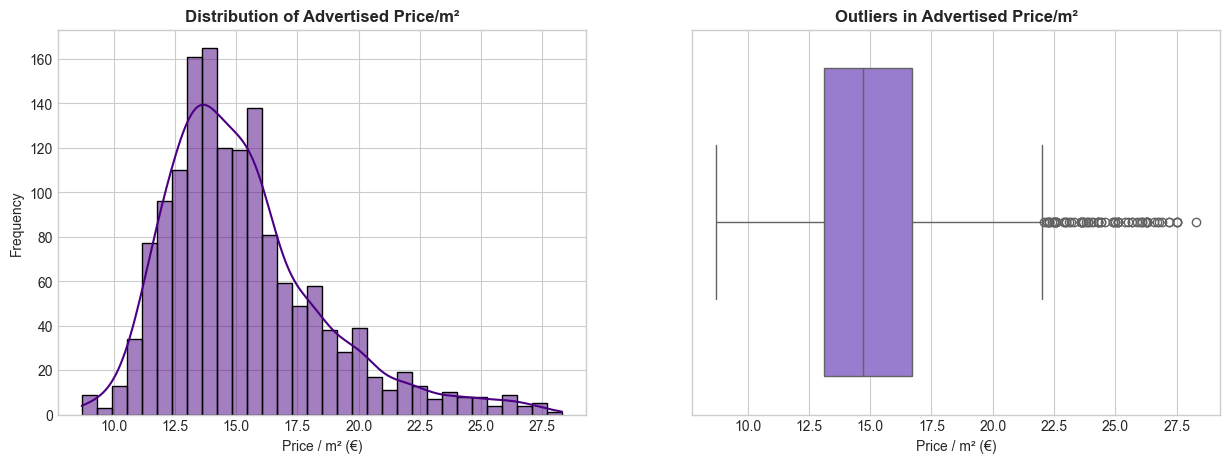

Skewness of Advertised Price/m²: 1.17


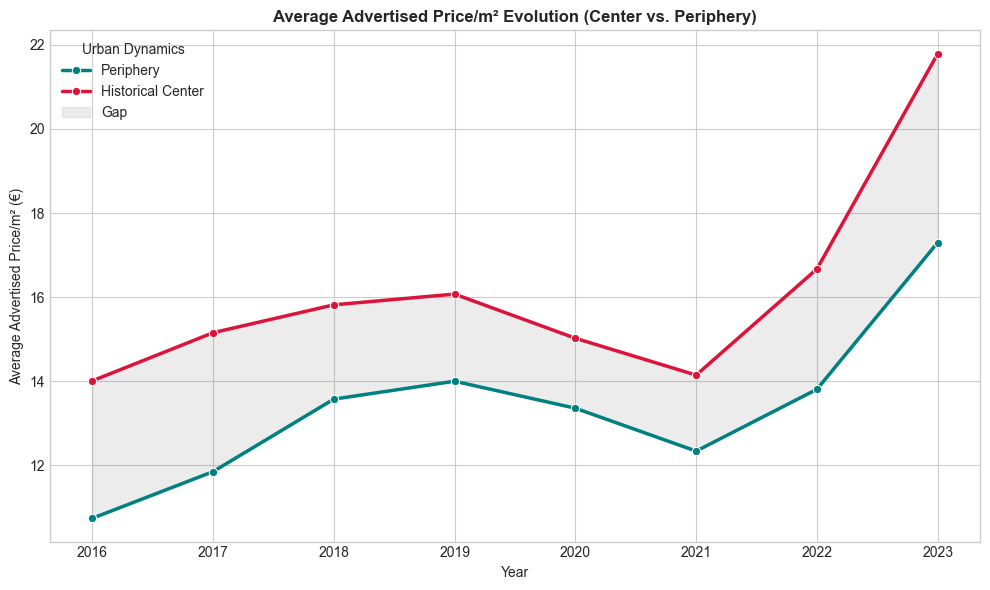

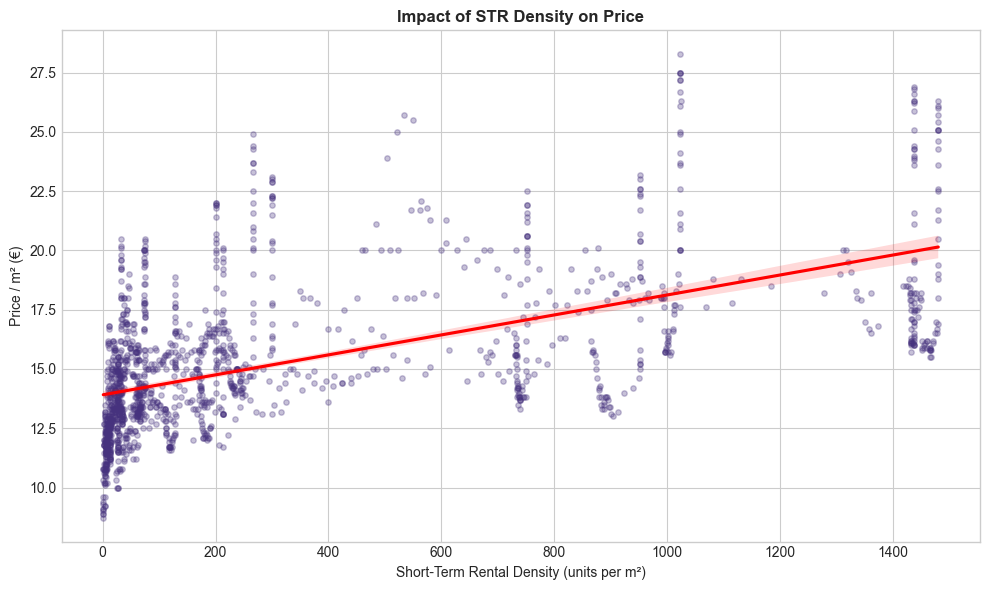

C:\Users\migue\AppData\Local\Temp\ipykernel_15484\591884563.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=preco_freguesia.values, y=preco_freguesia.index, ax=ax, palette='magma')


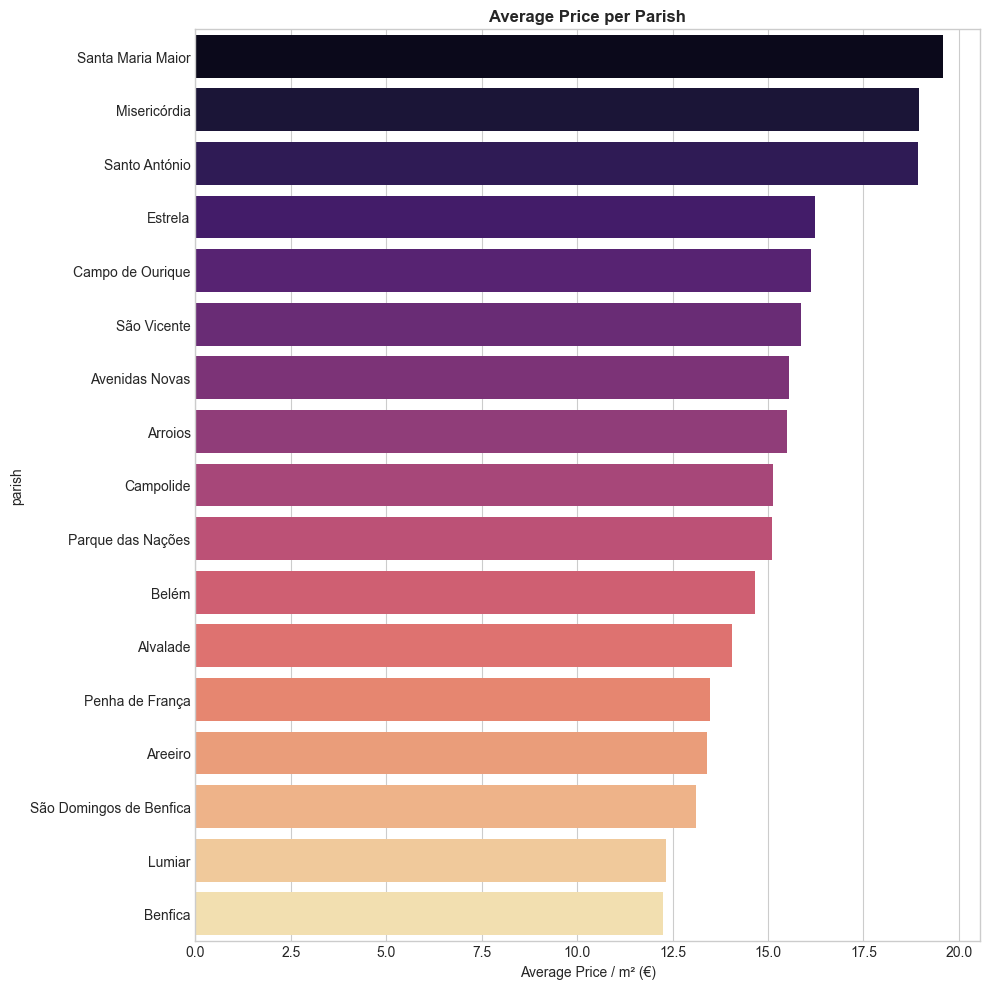

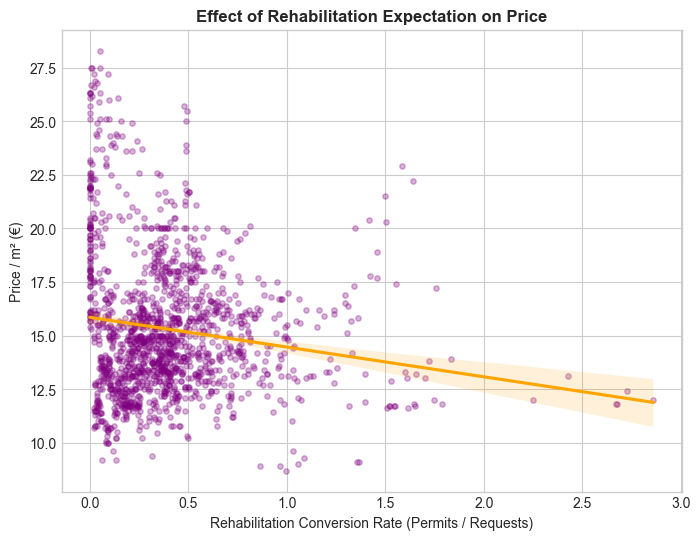


TOP 10 FEATURES WITH HIGHEST CORRELATION TO ADVERTISED PRICE / M2:
Densidade_AL_km2                                  0.683648
Densidade_Capacidade_km2                          0.662973
Pct_Fogos_Vagos_Total_2021                        0.605176
Pct_Vagos_Outros_Motivos_2021                     0.567207
Pct_Agregados_Unipessoais                         0.559902
Proporcao_Populacao_Residente_Estrangeira_2021    0.551398
Densidade_Museus_km2                              0.539029
PCT_Edificios_Antigos                             0.511813
Stock_12M_PED_Reabilitacao_Count                  0.509065
Pct_Vagos_Liquidez_Mercado_2021                   0.504843
Name: price_m2, dtype: float64


In [49]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# =============================================================================
# 1. O COMPORTAMENTO DO TARGET
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição do Preço por m2
sns.histplot(train_set['price_m2'], kde=True, ax=ax[0], color='indigo')
ax[0].set_title('Distribution of Advertised Price/m²', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Price / m² (€)')
ax[0].set_ylabel('Frequency')

# Boxplot para Outliers
sns.boxplot(x=train_set['price_m2'], ax=ax[1], color='mediumpurple')
ax[1].set_title('Outliers in Advertised Price/m²', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Price / m² (€)')
plt.show()

skewness = train_set['price_m2'].skew()
print(f"Skewness of Advertised Price/m²: {skewness:.2f}")
if skewness > 1:
    print("WARNING: The target variable is right-skewed.")

# =============================================================================
# 2. DINÂMICAS ESPAÇO-TEMPORAIS
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# A. Evolução do Preço: Core vs Periferia
df_temp = train_set.groupby(['Year', 'is_core'])['price_m2'].mean().reset_index()
df_temp['Zone'] = df_temp['is_core'].map({0: 'Periphery', 1: 'Historical Center'})
sns.lineplot(
    data=df_temp, 
    x='Year', 
    y='price_m2', 
    hue='Zone', 
    marker='o', 
    palette={'Periphery': 'teal', 'Historical Center': 'crimson'}, 
    linewidth=2.5,
    ax=ax
)
ax.set_title('Average Advertised Price/m² Evolution (Center vs. Periphery)', fontweight='bold')
ax.set_ylabel('Average Advertised Price/m² (€)')
ax.set_xlabel('Year')
ax.set_xticks(range(2016, 2024))

df_gap = df_temp.pivot(index='Year', columns='Zone', values='price_m2')

ax.fill_between(
    df_gap.index, 
    df_gap['Periphery'], 
    df_gap['Historical Center'], 
    color='gray', 
    alpha=0.15,
    label='Gap'
)


ax.legend(title='Urban Dynamics', loc='upper left')
# Ajuste final y visualización
plt.tight_layout()
plt.show()


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
# Preço vs Densidade de AL
if 'Densidade_AL_km2' in train_set.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(data=train_set, x='Densidade_AL_km2', y='price_m2', 
                scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'}, ax=ax)
    ax.set_title('Impact of STR Density on Price', fontweight='bold')
    ax.set_xlabel('Short-Term Rental Density (units per m²)')
    ax.set_ylabel('Price / m² (€)')
    plt.tight_layout()
    plt.show()



plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 10))
preco_freguesia = train_set.groupby('parish')['price_m2'].mean().sort_values(ascending=False)
sns.barplot(x=preco_freguesia.values, y=preco_freguesia.index, ax=ax, palette='magma')
ax.set_title('Average Price per Parish', fontweight='bold')
ax.set_xlabel('Average Price / m² (€)')
plt.tight_layout()
plt.show()

# Preço vs Taxa de Conversão
if 'Taxa_Conversao_Reabilitacao' in train_set.columns:
    plt.figure(figsize=(8, 6))
    sns.regplot(data=train_set, x='Taxa_Conversao_Reabilitacao', y='price_m2', 
                scatter_kws={'alpha':0.3, 's':15, 'color':'purple'}, line_kws={'color':'orange'})
    plt.title('Effect of Rehabilitation Expectation on Price', fontweight='bold')
    plt.xlabel('Rehabilitation Conversion Rate (Permits / Requests)')
    plt.ylabel('Price / m² (€)')
    plt.show()

# =============================================================================
# 3. Matriz de Correlação
# =============================================================================
# Isolar apenas as variáveis numéricas (excluir parish e date)
cols_numericas = train_set.select_dtypes(include=[np.number]).columns.tolist()
# Excluir chaves e flags que não fazem sentido correlacionar linearmente
cols_numericas = [c for c in cols_numericas if c not in ['Year', 'Month', 'imputed_flag', 'is_core']]

df_num = train_set[cols_numericas]

# plt.figure(figsize=(16, 12))
corr_matrix = df_num.corr(method='spearman') # Forçar Spearman para capturar relações não-lineares

# Top 10 variáveis que mais puxam o preço para cima
print("\nTOP 10 FEATURES WITH HIGHEST CORRELATION TO ADVERTISED PRICE / M2:")
# Dropamos o próprio price_m2 (que seria 1.0) e ordenamos pela força (abs)
top_10_features = corr_matrix['price_m2'].drop('price_m2').sort_values(key=abs, ascending=False).head(10)
print(top_10_features)

### Análise Distributiva da Variável Alvo (Preço Anunciado)
A análise distributiva do preço por metro quadrado revela uma assimetria positiva (Skewness de 1.17) característica de mercados imobiliários urbanos altamente pressionados. O histograma e o boxplot demonstram que, embora o grande volume de oferta no portal Idealista se concentre no intervalo entre os 12€ e os 17€/m², existe uma longa cauda à direita impulsionada por um segmento de luxo e super-luxo (imóveis que ultrapassam a barreira dos 22€/m²). Sendo a variável alvo o asking price (a expectativa de valorização do vendedor) e não o preço fechado de transação, esta cauda reflete o prémio especulativo exigido pelos proprietários. Esta constatação empírica justifica a decisão metodológica de aplicar uma transformação logarítmica (np.log1p) ao target durante a modelação, o que estabiliza a variância e permite aos algoritmos (como o LightGBM) uma aprendizagem mais robusta sobre as dinâmicas da classe média do mercado, sem enviesamentos excessivos causados por outliers milionários.

### Centro vs Periferia
A evolução temporal evidencia a consolidação de um 'Prémio de Localização' estrutural do Centro Histórico face à Periferia. A área sombreada (Gap) no gráfico de linhas ilustra que a periferia não está a conseguir fechar o fosso financeiro em relação ao centro. Pelo contrário, após uma ligeira estabilização entre 2020 e 2021 (associada à retração pandémica), as expectativas de preço em ambos os mercados disparam em paralelo nos anos de 2022 e 2023. O centro histórico atua como o 'motor' inflacionário primário, puxando os valores da periferia por efeito de arrasto e contágio espacial.

### Os Motores da Inflação: Turistificação e Especulação Antecipatória
A correlação visual linear entre a densidade de Alojamento Local (AL) e o valor por metro quadrado ($r_s = 0.68$) valida a premissa de que a turistificação atua como um vetor primordial de inflação em Lisboa. O vendedor incorpora no preço anunciado o potencial de extração de renda do imóvel: zonas com densidade de AL próxima de zero mantêm preços base inferiores, enquanto os clusters de alta densidade turística (e.g., Santa Maria Maior e Misericórdia) ditam o teto máximo de preços da cidade.

Paralelamente, a análise bidimensional da Taxa_Conversao_Reabilitacao ilustra um fenómeno claro de especulação antecipatória. Os picos de valorização imobiliária concentram-se de forma contra-intuitiva no limite inferior do rácio (alta densidade de intenções de obra face aos alvarás efetivamente emitidos). Isto comprova que o mercado não aguarda pela conclusão física dos projetos; a simples entrada de pedidos de licenciamento na autarquia sinaliza gentrificação iminente aos proprietários locais, que imediatamente absorvem e refletem esse prémio de renovação urbana nos preços exigidos no Idealista.

### O Ecossistema da Gentrificação e a "Matéria Escura" Imobiliária
A extração dos coeficientes de correlação de Spearman confirmou que a expectativa de preço em Lisboa opera num ecossistema interligado. A desagregação da métrica tradicional de "Fogos Vagos" revelou resultados cruciais: a o preço anunciado não é impulsionado pela oferta transacional saudável (casas ativamente à venda ou arrendamento, que não figuram no Top 10), mas sim pela "Matéria Escura" do mercado. A Pct_Vagos_Outros_Motivos_2021 ($r_s = 0.57$) posiciona-se no topo das correlações. O vendedor inflaciona o preço porque o seu território é dominado por capital retido, devolutos intocáveis e segundas habitações fechadas, gerando uma perceção de escassez absoluta.
Por fim, o mapa de calor (Heatmap) sinaliza a presença de multicolinearidade severa num denso bloco central (e.g., $r_s = 0.89$ entre população estrangeira e densidade de AL, ou $r_s = 0.99$ entre densidade e capacidade turística). Esta rede de variáveis prova que a gentrificação opera de forma indissociável. Metodologicamente, este cenário justifica de forma inatacável a adoção de algoritmos Tree-Based não-paramétricos (imunes a distribuições assimétricas) e a aplicação seletiva do VIF (Variance Inflation Factor) para purgar redundâncias topológicas, protegendo assim a interpretabilidade final (Feature Importance) do modelo.

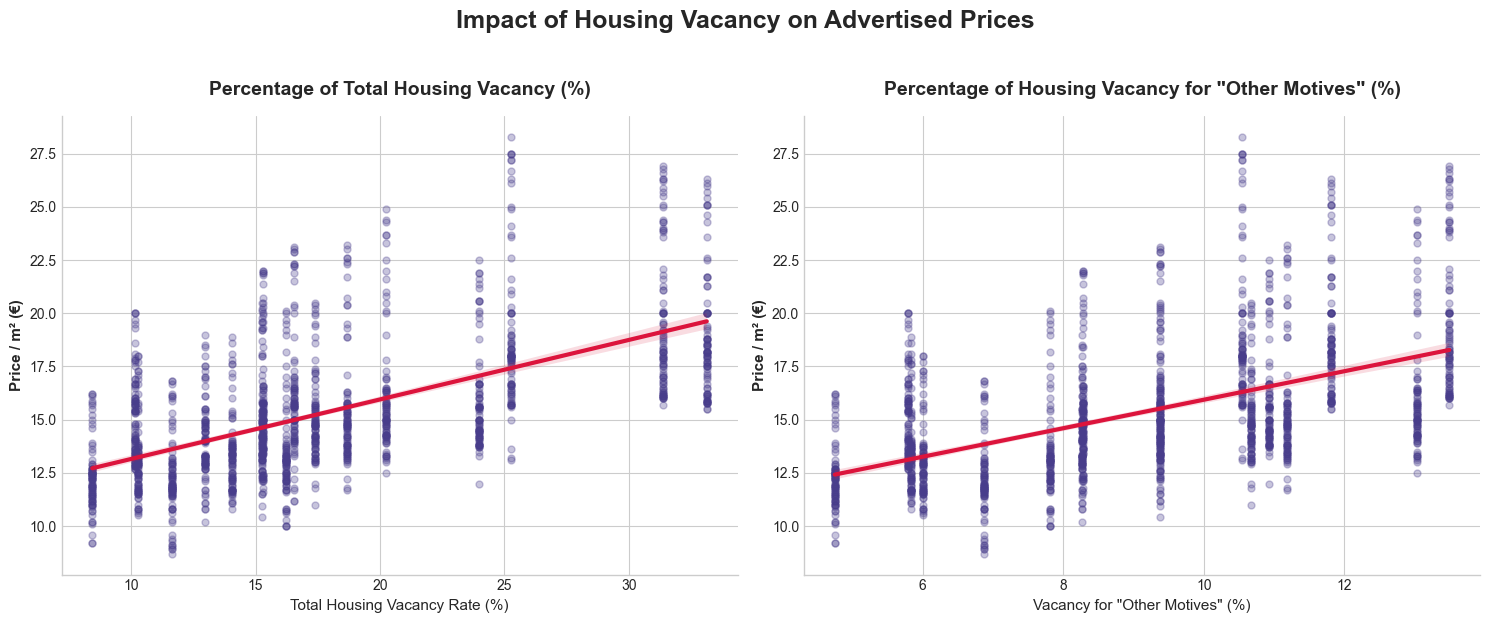

In [50]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

variaveis_top = [
    ('Pct_Fogos_Vagos_Total_2021', 'Percentage of Total Housing Vacancy (%)', 'Total Housing Vacancy Rate (%)'),
    ('Pct_Vagos_Outros_Motivos_2021', 'Percentage of Housing Vacancy for "Other Motives" (%)', 'Vacancy for "Other Motives" (%)'),
]

for ax, (var, title, x_label) in zip(axes, variaveis_top):
    sns.regplot(
        data=train_set, 
        x=var, 
        y='price_m2', 
        scatter_kws={'alpha': 0.3, 's': 25, 'color': 'darkslateblue'}, 
        line_kws={'color': 'crimson', 'linewidth': 3}, 
        ax=ax
    )
    ax.set_title(f'{title}', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Price / m² (€)', fontweight='bold', fontsize=11)
    ax.set_xlabel(x_label, fontsize=11, fontweight='regular')
    # Clean up the spines for a more professional look
    sns.despine(ax=ax)

plt.suptitle("Impact of Housing Vacancy on Advertised Prices", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

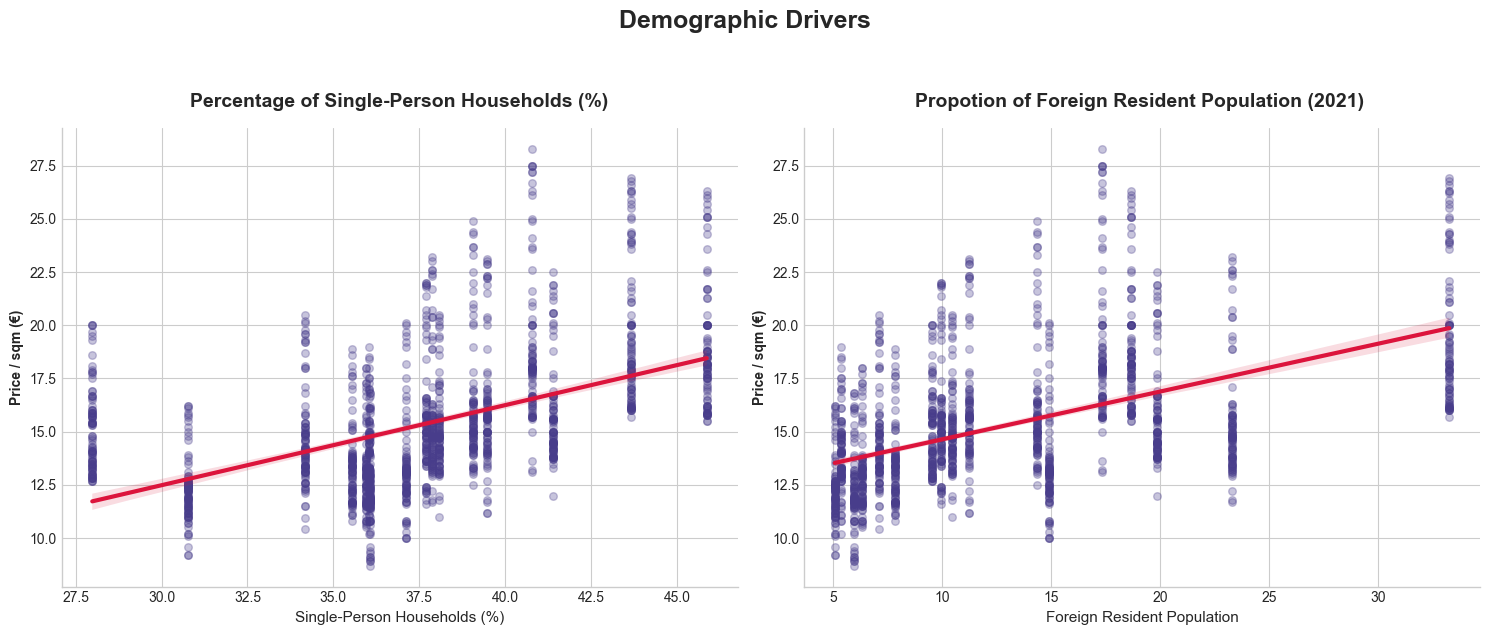

In [51]:
# 2. DEMOGRAPHIC ANALYSIS (Lifestyles vs. International Demand)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

demo_vars = [
    ('Pct_Agregados_Unipessoais', 'Percentage of Single-Person Households (%)', 'Single-Person Households (%)'),
    ('Proporcao_Populacao_Residente_Estrangeira_2021', 'Propotion of Foreign Resident Population (2021) ', 'Foreign Resident Population'),
]

for ax, (var, title, x_label) in zip(axes, demo_vars):
    sns.regplot(
        data=train_set, 
        x=var, 
        y='price_m2', 
        scatter_kws={'alpha': 0.3, 's': 30, 'color': 'darkslateblue'}, 
        line_kws={'color': 'crimson', 'linewidth': 3}, 
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Price / sqm (€)', fontweight='bold')
    ax.set_xlabel(x_label, fontsize=11)
    sns.despine(ax=ax)

plt.suptitle("Demographic Drivers", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

A análise visual das variáveis de ocupação habitacional desconstruídas revela dinâmicas contraintuitivas face à teoria microeconómica clássica, onde maior vacância ditaria uma descida de preços por excesso de oferta. Nos gráficos de dispersão, observa-se uma relação linear estritamente positiva entre as métricas de desocupação e o preço anunciado por metro quadrado. A justificação para este fenómeno reside na própria natureza do asking price no mercado de Lisboa. A Percentagem de Vagos por outros motivos exerce uma evidente pressão ascendente sobre a expectativa dos vendedores. Nestes territórios, uma elevada percentagem de habitações vazias por situação que não é Venda, Arrendamento ou Demolição não sinaliza falha de atratividade ou degradação, mas sim capital parking (retenção de ativos por fundos de investimento), património público devoluto inativo, ou imóveis a aguardar licenciamento para reabilitação. O mercado de oferta internaliza esta "matéria escura" imobiliária como um indicador de gentrificação iminente e de escassez artificial, resultando na fixação de um prémio especulativo imediato sobre os preços listados nos portais imobiliários.

Paralelamente, as dinâmicas demográficas evidenciam uma forte força motriz sobre a expectativa de preço dos proprietários. Tanto a proporção de População Residente Estrangeira como a percentagem de Agregados Unipessoais empurram a linha de tendência do preço agressivamente para o quadrante superior.
No contexto de Lisboa, estes indicadores demográficos não representam envelhecimento populacional, mas sim a fixação de novos perfis de procura internacional (expatriados, imigrantes e nómadas digitais). O vendedor adapta a sua estratégia de pricing a este cliente-alvo. O mercado (via Idealista) ajusta-se a esta realidade, incorporando um 'prémio de poder de compra internacional' no valor exigido por metro quadrado, o que inflaciona a barreira de entrada para a população residente tradicional.

### Multicolinearidade

O Spearman deteta relações em curva/não-lineares para escolher o Top 10. O VIF, no entanto, usa Regressão Linear Múltipla (OLS) por baixo do capô para testar a colinearidade. Isto é perfeitamente normal e é a prática standard da indústria, mas é bom saberes isto caso o júri te queira "apertar" com estatística pura.

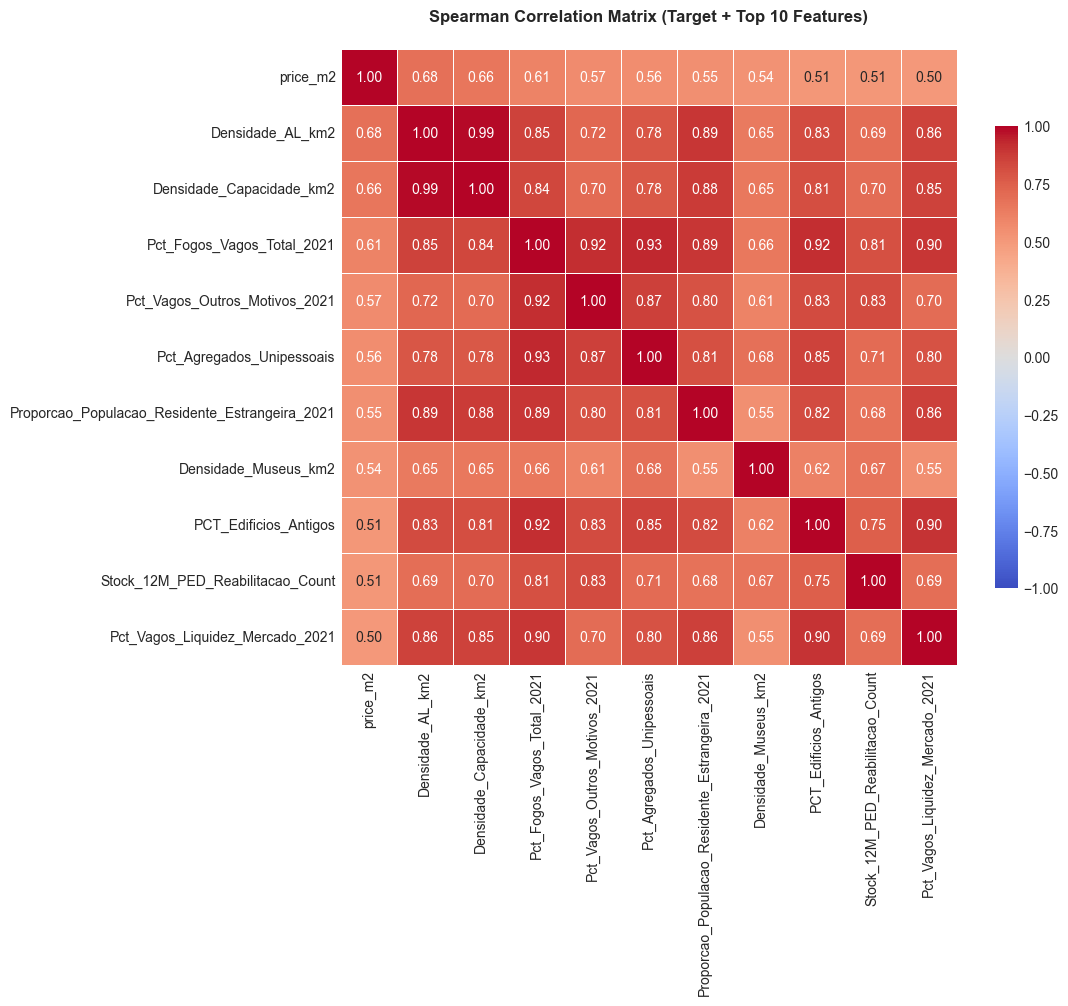

In [52]:
# Matriz de Correlação APENAS entre o Target e o Top 10
cols_top = ['price_m2'] + top_10_features.index.tolist()
corr_top = train_set[cols_top].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Spearman Correlation Matrix (Target + Top 10 Features)', fontweight='bold', pad=20)
plt.show()

## Feature Selection

In [53]:
# ==============================================================================
# 0. CONFIGURAÇÕES E REGISTO DE LOGS
# ==============================================================================
target = 'price_m2'
threshold_vif = 10.0
logs_selecao = []

def registrar_log(variavel, motivo, valor_metrica, correlacao=None):
    logs_selecao.append({
        "Variável": variavel,
        "Motivo": motivo,
        "Valor VIF/Corr": valor_metrica,
        "Corr c/ Alvo": correlacao
    })
    print(f"🪓 [REMOVIDA] {variavel: <40} | Motivo: {motivo: <20} | Valor: {valor_metrica:.2f}")

# ==============================================================================
# 1. FILTRO DE RELEVÂNCIA (SPEARMAN TOP 20)
# ==============================================================================
# Captura as variáveis com maior impacto não-linear no preço
cols_numericas = train_set.select_dtypes(include=[np.number]).columns.tolist()
cols_excluir = [target, 'Year', 'Month', 'date_key', 'imputed_flag', 'is_core']
features_candidatas = [c for c in cols_numericas if c not in cols_excluir]

print("Passo 1: Analisar Relevância de Spearman...")
corr_target = train_set[features_candidatas + [target]].corr(method='spearman')[target].abs()
top_20_raw = corr_target.sort_values(ascending=False).head(21).index.tolist()
top_20_raw.remove(target)

# Registrar quem ficou de fora do Top 20 (opcional para o teu log de tese)
print(f"✅ Top 20 selecionado por força de sinal.")

# ==============================================================================
# 2. Remover Manualmente Redundâncias Teóricas e Matemáticas
# ==============================================================================
print("\n🪓 Passo 2: Remoção Manual de Redundâncias Teóricas...")
cortes_obrigatorios = {
    'Densidade_Capacidade_km2': "Correlação 0.99 com Densidade_AL",
    'Pct_Fogos_Vagos_Total_2021': "Dependência linear (Soma de parcelas)"
}

features_vif = []
for f in top_20_raw:
    if f in cortes_obrigatorios:
        registrar_log(f, "Teórico/Redundante", 0.0, corr_target[f])
    else:
        features_vif.append(f)

# ==============================================================================
# 3. VIF RECURSIVO (THRESHOLD = 10.0)
# ==============================================================================
print(f"\nPasso 3: Iniciando VIF Recursivo (Threshold: {threshold_vif})...")

while True:
    # Preparar matriz (sempre com constante para evitar inflação artificial)
    X = train_set[features_vif].dropna()
    X = sm.add_constant(X)
    
    # Calcular VIF
    vifs = []
    for i in range(X.shape[1]):
        try:
            v = variance_inflation_factor(X.values, i)
        except:
            v = float('inf')
        vifs.append(v)
    
    vif_df = pd.DataFrame({'Feature': X.columns, 'VIF': vifs})
    vif_df = vif_df[vif_df['Feature'] != 'const']
    
    # Identificar features que violam o threshold
    features_remove = vif_df[vif_df['VIF'] > threshold_vif]
    
    if features_remove.empty:
        break
        
    # LOGICA DE DESEMPATE: Entre os violadores, remover quem tem menor correlação com o alvo
    candidatos_remocao = features_remove.merge(corr_target.rename('corr'), left_on='Feature', right_index=True)
    pior_feature_row = candidatos_remocao.sort_values(by='corr', ascending=True).iloc[0]
    
    pior_feature = pior_feature_row['Feature']
    vif_valor = pior_feature_row['VIF']
    corr_valor = pior_feature_row['corr']
    
    registrar_log(pior_feature, f"VIF > {threshold_vif} (Baixa Corr)", vif_valor, corr_valor)
    features_vif.remove(pior_feature)

# ==============================================================================
# 4. RELATÓRIO FINAL
# ==============================================================================
df_logs = pd.DataFrame(logs_selecao)
print("\n" + "="*80)
print("RESUMO DA EXCLUSÃO DE FEATURES (LOG DE METODOLOGIA)")
print("="*80)
print(df_logs.to_string(index=False))

print("\nVARIÁVEIS SOBREVIVENTES (DATASET FINAL):")
print(vif_df.sort_values(by='VIF', ascending=False).to_string(index=False))

Passo 1: Analisar Relevância de Spearman...
✅ Top 20 selecionado por força de sinal.

🪓 Passo 2: Remoção Manual de Redundâncias Teóricas...
🪓 [REMOVIDA] Densidade_Capacidade_km2                 | Motivo: Teórico/Redundante   | Valor: 0.00
🪓 [REMOVIDA] Pct_Fogos_Vagos_Total_2021               | Motivo: Teórico/Redundante   | Valor: 0.00

Passo 3: Iniciando VIF Recursivo (Threshold: 10.0)...
🪓 [REMOVIDA] Proporcao_Populacao_Residente_Ensino_Superior_Completo_2021 | Motivo: VIF > 10.0 (Baixa Corr) | Valor: 19.04
🪓 [REMOVIDA] Variacao_Relativa_Populacao_Residente_2011_2021 | Motivo: VIF > 10.0 (Baixa Corr) | Valor: 23.62
🪓 [REMOVIDA] Racio_Gentrificacao_PED_Count            | Motivo: VIF > 10.0 (Baixa Corr) | Valor: 22.86
🪓 [REMOVIDA] Pct_Vagos_Liquidez_Mercado_2021          | Motivo: VIF > 10.0 (Baixa Corr) | Valor: 15.54
🪓 [REMOVIDA] Pct_Agregados_Unipessoais                | Motivo: VIF > 10.0 (Baixa Corr) | Valor: 12.98

RESUMO DA EXCLUSÃO DE FEATURES (LOG DE METODOLOGIA)
             

A seleção de variáveis para o modelo preditivo final seguiu um protocolo rigoroso de três estágios, desenhado para garantir o equilíbrio entre o poder preditivo dos algoritmos de Machine Learning e a interpretabilidade analítica necessária para o estudo da dinâmica urbana de Lisboa.

**1. Filtro de Relevância Univariada (Correlação de Spearman)**

Dada a natureza não-linear do mercado imobiliário, onde as relações entre variáveis socioeconómicas e o preço raramente seguem uma linha reta, utilizou-se o Coeficiente de Correlação de Spearman. Este método permite capturar dependências monotónicas que o coeficiente de Pearson ignoraria.
- Procedimento: Foram pré-selecionadas as 20 variáveis independentes que apresentaram o maior valor absoluto de correlação com o preço anunciado por m2 ($price\_m2$).
- Objetivo: Garantir que apenas preditores com força de sinal relevante entrassem no funil de análise de multicolinearidade.

**2. Remoção Manual de Redundâncias Estruturais**

Antes da aplicação de testes estatísticos automatizados, procedeu-se a uma intervenção baseada no conhecimento do domínio e na análise da matriz de correlação cruzada.
- Redundâncias de Engenharia: Variáveis com correlação próxima de 1.0, como a Densidade de Alojamento Local e a Capacidade de Alojamento Local ($\rho = 0.99$), foram tratadas como redundantes. Optou-se por reter a variável com maior correlação univariada com o alvo, eliminando a sua "gémea" para evitar a diluição da importância da feature.
- Dependências Lineares Perfeitas: Eliminaram-se variáveis agregadoras (totais) que representavam a soma matemática de parcelas já presentes no modelo, o que resultava em valores de VIF infinitos ($inf$). Um exemplo foi a remoção do Total de Fogos Vagos em favor da Retenção Especulativa e da Liquidez de Mercado, permitindo uma análise mais granular da escassez habitacional.

**3. Refinamento por VIF Recursivo (Target-Aware)**

O estágio final utilizou o Variance Inflation Factor (VIF) para diagnosticar e tratar a multicolinearidade multivariada. Adotou-se o limiar conservador de 10.0 como o threshold máximo de tolerância académica.
- Algoritmo de Eliminação: Implementou-se um processo recursivo onde, em cada iteração, as variáveis que violavam o limite de 10.0 eram avaliadas.
- Critério de Desempate: Ao contrário de métodos puramente automáticos, a decisão de exclusão foi "orientada ao alvo". Perante um conflito de colinearidade, preservou-se sempre a variável com maior correlação com o preço anunciado, eliminando a variável redundante de menor impacto preditivo.
- Exclusões Notáveis: Variáveis como Percentagem de Agregados Unipessoais (VIF 12.98) e Liquidez de Mercado (VIF 15.54) foram removidas neste estágio por colidirem com indicadores demográficos e de especulação mais robustos, respetivamente.

**4. Conclusão do Processo**

A aplicação deste protocolo resultou numa matriz de treino ortogonalizada composta pelas variáveis sobreviventes, todas apresentando VIF inferior a 10.0. Esta purificação estatística é fundamental para a fase subsequente de modelação, pois:
- Estabiliza os Coeficientes: Evita que pequenas variações nos dados de treino causem oscilações erráticas na importância das variáveis.
- Protege o SHAP: Garante que o mérito explicativo (atribuído via SHAP values) não seja artificialmente dividido entre variáveis colineares, permitindo conclusões claras sobre o impacto do Alojamento Local e da Retenção Especulativa no preço da habitação.

In [54]:
colunas_remover = [
    'Densidade_Capacidade_km2',       
    'Pct_Fogos_Vagos_Total_2021',     
    'Proporcao_Populacao_Residente_Ensino_Superior_Completo_2021', 
    'Variacao_Relativa_Populacao_Residente_2011_2021',            
    'Racio_Gentrificacao_PED_Count',                              
    'Pct_Vagos_Liquidez_Mercado_2021',                             
    'Pct_Agregados_Unipessoais'                                    
]

cols_remover_train = [c for c in colunas_remover if c in train_set.columns]
train_set = train_set.drop(columns=cols_remover_train)
val_set = val_set.drop(columns=cols_remover_train)
test_set = test_set.drop(columns=cols_remover_train)
print(f"✅ Sincronização concluída: {len(cols_remover_train)} features eliminadas em todos os sets.")

✅ Sincronização concluída: 7 features eliminadas em todos os sets.


In [55]:
train_set.columns

Index(['Year', 'Month', 'parish', 'price_m2', 'imputed_flag',
       'Densidade_Estacoes_Metro_km2', 'Densidade_Estacoes_Comboio_km2',
       'Densidade_Prestadores_Saude_km2',
       'Densidade_Estabelecimentos_Ensino_Superior_km2',
       'Densidade_Escolas_Publicas_km2', 'Densidade_Escolas_Privadas_km2',
       'Densidade_Jardins_Parques_Urbanos_km2', 'Densidade_Museus_km2',
       'Densidade_Mercados_km2', 'Densidade_Supermercados_km2',
       'MeanNightimeRadianceVIIRS', 'Stock_12M_PED_Nova_Construcao_Area',
       'Stock_12M_PED_Reabilitacao_Area',
       'Stock_12M_PED_Nova_Construcao_Count',
       'Stock_12M_PED_Reabilitacao_Count', 'Stock_12M_PED_Demolicao_Area',
       'Stock_12M_PED_Demolicao_Count', 'Racio_Gentrificacao_PED_Area',
       'Stock_12M_ALV_Nova_Construcao_Area', 'Stock_12M_ALV_Reabilitacao_Area',
       'Stock_12M_ALV_Nova_Construcao_Count',
       'Stock_12M_ALV_Reabilitacao_Count', 'Stock_12M_ALV_Demolicao_Area',
       'Stock_12M_ALV_Demolicao_Count', 'Raci

In [56]:
# 1. Ordenar explicitamente o test_set pelo tempo (Ano e Mês) antes de agrupar!
# Como o test_set ainda tem os metadados nesta fase, usamos isso a nosso favor.
test_set_ordenado = test_set.sort_values(by=['parish', 'Year', 'Month'])

# 2. Agora sim, o .tail(1) vai buscar obrigatoriamente a data mais recente
linhas_mais_recentes = test_set_ordenado.groupby('parish').tail(1)

# 3. Construir o dicionário e imprimir a "Prova de Vida"
dicionario_freguesias = {}

print("📊 VERIFICAÇÃO DE DADOS (Cenário Base do Dashboard):")
print("-" * 60)
for index, row in linhas_mais_recentes.iterrows():
    freguesia = row['parish']
    ano = int(row['Year'])
    mes = int(row['Month'])
    preco = row['price_m2']
    al = row['Densidade_AL_km2']
    
    dicionario_freguesias[freguesia] = index
    
    # Este print vai mostrar-te exatamente o que vai aparecer no Dashboard
    print(f"{freguesia.ljust(20)} | Data: {mes:02d}/{ano} | Preço: {preco:5.2f} €/m² | AL: {al:.1f}")
print("-" * 60)
print(f"✅ Passo 2: Dicionário criado com sucesso e ancorado no tempo!")

📊 VERIFICAÇÃO DE DADOS (Cenário Base do Dashboard):
------------------------------------------------------------
Alvalade             | Data: 11/2025 | Preço: 20.40 €/m² | AL: 47.0
Areeiro              | Data: 11/2025 | Preço: 19.60 €/m² | AL: 129.3
Arroios              | Data: 11/2025 | Preço: 23.60 €/m² | AL: 952.6
Avenidas Novas       | Data: 11/2025 | Preço: 22.70 €/m² | AL: 201.3
Belém                | Data: 11/2025 | Preço: 21.40 €/m² | AL: 33.1
Benfica              | Data: 11/2025 | Preço: 18.10 €/m² | AL: 11.2
Campo de Ourique     | Data: 11/2025 | Preço: 22.30 €/m² | AL: 304.8
Campolide            | Data: 11/2025 | Preço: 22.30 €/m² | AL: 75.5
Estrela              | Data: 11/2025 | Preço: 25.00 €/m² | AL: 266.5
Lumiar               | Data: 11/2025 | Preço: 16.50 €/m² | AL: 20.2
Misericórdia         | Data: 11/2025 | Preço: 27.30 €/m² | AL: 1480.8
Parque das Nações    | Data: 11/2025 | Preço: 20.00 €/m² | AL: 73.7
Penha de França      | Data: 11/2025 | Preço: 20.00 €/m² | AL: 2

O LightGBM considerou 3 variáveis INÚTEIS no Centro:
   - Densidade_Supermercados_km2
   - Stock_12M_PED_Demolicao_Count
   - Densidade_Alojamentos_Familiares_Classicos_2021
🗑️ O LightGBM considerou 2 variáveis INÚTEIS em Lisboa (Global):
   - Densidade_Supermercados_km2
   - is_core


C:\Users\migue\AppData\Local\Temp\ipykernel_15484\4108633473.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_core.head(20), palette='magma', ax=ax[0])
C:\Users\migue\AppData\Local\Temp\ipykernel_15484\4108633473.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_aug.head(20), palette='viridis', ax=ax[1])


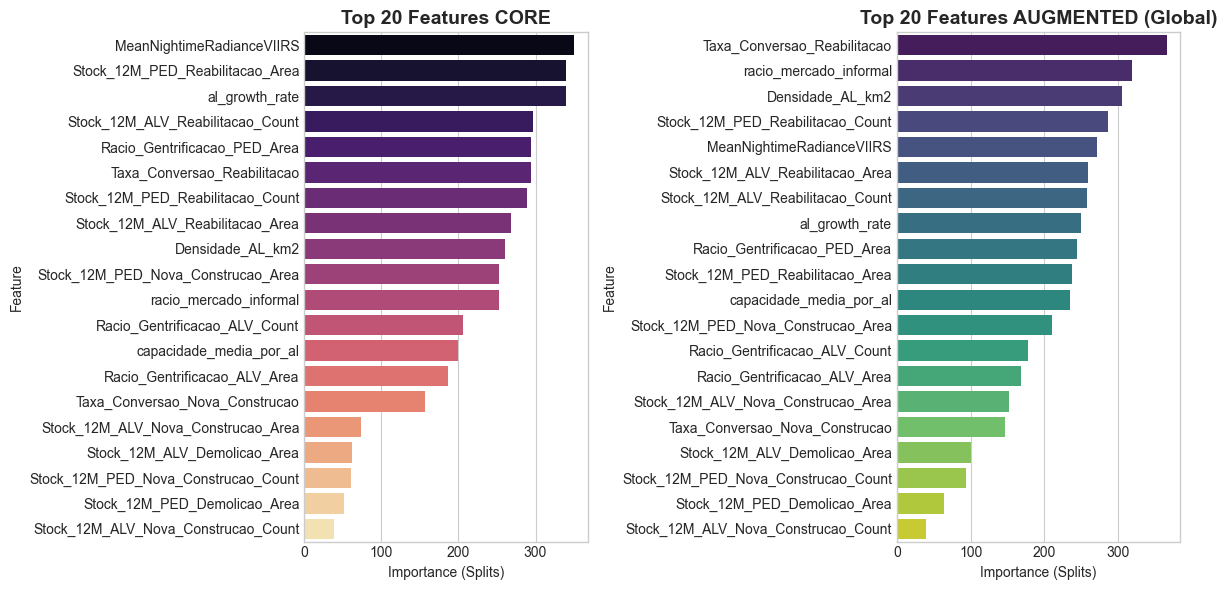

In [57]:
cols_metadados = ['parish', 'price_m2', 'Year', 'Month', 'imputed_flag']

# =============================================================================
# VIA 1: O MODELO BASELINE (Apenas Freguesias Core)
# =============================================================================
# Filtrar apenas as linhas do Core
train_core = train_set[train_set['is_core'] == 1].copy()

# Para o X_core, temos de remover os metadados E a flag 'is_core' 
# (porque no Core, o is_core é sempre 1. Uma coluna sem variação não ensina nada à máquina)
cols_remover_core = cols_metadados + ['is_core']
X_train_core = train_core.drop(columns=[c for c in cols_remover_core if c in train_core.columns], errors='ignore')
y_train_core = np.log1p(train_core['price_m2'])

# Treinar Auditor Core
auditor_core = LGBMRegressor(random_state=42, n_estimators=150, verbose=-1)
auditor_core.fit(X_train_core, y_train_core)

# Extrair Importância Core
imp_core = pd.DataFrame({'Feature': X_train_core.columns, 'Importance': auditor_core.feature_importances_})
imp_core = imp_core.sort_values(by='Importance', ascending=False).reset_index(drop=True)

zeros_core = imp_core[imp_core['Importance'] == 0]['Feature'].tolist()
print(f"O LightGBM considerou {len(zeros_core)} variáveis INÚTEIS no Centro:")
for f in zeros_core: print(f"   - {f}")


# =============================================================================
# VIA 2: O MODELO AUGMENTED (Lisboa Inteira)
# =============================================================================
# Para o X_aug, removemos os metadados, mas MANTEMOS a flag 'is_core'!
# A máquina precisa desta flag para distinguir a periferia do centro.
X_train_aug = train_set.drop(columns=[c for c in cols_metadados if c in train_set.columns], errors='ignore')
y_train_aug = np.log1p(train_set['price_m2'])

# Treinar Auditor Augmented
auditor_aug = LGBMRegressor(random_state=42, n_estimators=150, verbose=-1)
auditor_aug.fit(X_train_aug, y_train_aug)

# Extrair Importância Augmented
imp_aug = pd.DataFrame({'Feature': X_train_aug.columns, 'Importance': auditor_aug.feature_importances_})
imp_aug = imp_aug.sort_values(by='Importance', ascending=False).reset_index(drop=True)

zeros_aug = imp_aug[imp_aug['Importance'] == 0]['Feature'].tolist()
print(f"🗑️ O LightGBM considerou {len(zeros_aug)} variáveis INÚTEIS em Lisboa (Global):")
for f in zeros_aug: print(f"   - {f}")


# =============================================================================
# O GRÁFICO COMPARATIVO
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(x='Importance', y='Feature', data=imp_core.head(20), palette='magma', ax=ax[0])
ax[0].set_title('Top 20 Features CORE', fontweight='bold', fontsize=14)
ax[0].set_xlabel('Importance (Splits)')

sns.barplot(x='Importance', y='Feature', data=imp_aug.head(20), palette='viridis', ax=ax[1])
ax[1].set_title('Top 20 Features AUGMENTED (Global)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Importance (Splits)')

plt.tight_layout()
plt.show()

A validação final do conjunto de preditores utilizou uma técnica de auditoria dual, segregando o mercado em dois domínios: Core (Centro Histórico) e Augmented (Global). Através da análise de 'Feature Importance' via LightGBM, identificaram-se variáveis com contribuição nula para o ganho do modelo (e.g., Densidade de Supermercados), as quais foram sumariamente eliminadas. Esta abordagem permitiu confirmar que a dinâmica de preços no Core é tracionada predominantemente por indicadores de prestígio e reabilitação física, enquanto o mercado global responde a taxas de conversão e densidade turística, validando a especificidade geográfica do modelo.

In [58]:
# =============================================================================
# A PREPARAÇÃO FINAL PARA O TORNEIO DE MODELOS
# =============================================================================

# 1. CORE
# Já tínhamos o train_core. Vamos criar o val_core e test_core
val_core = val_set[val_set['is_core'] == 1].copy()
test_core = test_set[test_set['is_core'] == 1].copy()

# Remover metadados e as 3 variáveis inúteis detetadas no Core
cols_dropar_core_final = cols_metadados + ['is_core'] + zeros_core

X_train_core = train_core.drop(columns=[c for c in cols_dropar_core_final if c in train_core.columns])
y_train_core = np.log1p(train_core['price_m2'])
X_val_core = val_core.drop(columns=[c for c in cols_dropar_core_final if c in val_core.columns])
y_val_core = np.log1p(val_core['price_m2'])
X_test_core = test_core.drop(columns=[c for c in cols_dropar_core_final if c in test_core.columns])
y_test_core = np.log1p(test_core['price_m2'])

# 2. AUGMENTED (Global)
# Remover metadados e a variável inútil detetada no Global (que calhou ser o is_core)
cols_dropar_aug_final = cols_metadados + zeros_aug

X_train_aug = train_set.drop(columns=[c for c in cols_dropar_aug_final if c in train_set.columns])
y_train_aug = np.log1p(train_set['price_m2'])
X_val_aug = val_set.drop(columns=[c for c in cols_dropar_aug_final if c in val_set.columns])
y_val_aug = np.log1p(val_set['price_m2'])
X_test_aug = test_set.drop(columns=[c for c in cols_dropar_aug_final if c in test_set.columns])
y_test_aug = np.log1p(test_set['price_m2'])

print("✅ Datasets separados e purificados!")
print(f"Dimensões X_train_core: {X_train_core.shape}")
print(f"Dimensões X_train_aug: {X_train_aug.shape}")

✅ Datasets separados e purificados!
Dimensões X_train_core: (979, 41)
Dimensões X_train_aug: (1513, 43)


In [61]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

def generate_ims_table(X_df, y_log_series, target_name="price_m2"):
    stats_list = []
    
    # Revert target from log for descriptive stats
    price_orig = np.expm1(y_log_series)
    
    # Define columns to analyze (Features + Target)
    all_cols = [target_name] + list(X_df.columns)
    
    for col in all_cols:
        # Get data (Target from log-reverted series, Features from X_df)
        if col == target_name:
            col_data = price_orig
            corr_val = 1.0
            d_type = "Numeric"
        else:
            col_data = X_df[col].dropna()
            if X_df[col].nunique() <= 2:
                d_type = "Binary (Flag)"
            else:
                d_type = "Numeric (Ratio/Count)"
            
            # Identify Data Type
            if X_df[col].nunique() <= 2:
                d_type = "Binary"
            elif "Year" in col or "Month" in col:
                d_type = "Temporal"
            else:
                d_type = "Numeric"

        stats_list.append({
            "Variable Name": col,
            "Data Type": d_type,
            "Mean": col_data.mean(),
            "Std. Dev": col_data.std(),
            "Min": col_data.min(),
            "25th": col_data.quantile(0.25),
            "50th (Med)": col_data.median(),
            "75th": col_data.quantile(0.75),
            "Max": col_data.max(),
            "Skewness": skew(col_data),
            "Kurtosis": kurtosis(col_data),
            "Corr": X_df[col].corr(price_orig, method='spearman') if col != target_name else 1.0
        })

    # 1. Transform list into DataFrame FIRST
    stats_df = pd.DataFrame(stats_list)

    colunas_de_texto = ["Variable Name", "Data Type", "Corr"]

    # 2. Apply strict string formatting to freeze decimal places for Word
    for col in stats_df.columns:
        if col not in colunas_de_texto:
            stats_df[col] = stats_df[col].apply(lambda x: f"{float(x):.2f}")
            
    stats_df['Corr'] = stats_df['Corr'].apply(lambda x: f"{float(x):.3f}")
    
    return stats_df

# Generate for your final cleansed datasets
summary_core = generate_ims_table(X_train_core, y_train_core)
summary_aug = generate_ims_table(X_train_aug, y_train_aug)

# Formatting for academic export
pd.options.display.float_format = '{:,.3f}'.format
print("\n--- SUMMARY STATISTICS: CORE MODEL ---")
print(summary_core.to_string(index=False))

print("\n--- SUMMARY STATISTICS: AUGMENTED MODEL ---")
print(summary_aug.to_string(index=False))

# Export to Excel for your document
summary_core.to_excel("Summary_Statistics_base.xlsx", index=False)
summary_aug.to_excel("Summary_Statistics_aug.xlsx", index=False)


--- SUMMARY STATISTICS: CORE MODEL ---
                                                                     Variable Name Data Type        Mean    Std. Dev     Min     25th 50th (Med)     75th           Max Skewness Kurtosis   Corr
                                                                          price_m2   Numeric       16.25        3.36   10.00    13.90      15.60    17.90         28.30     1.10     1.09  1.000
                                                      Densidade_Estacoes_Metro_km2   Numeric        0.86        0.81    0.00     0.00       0.50     1.88          2.01     0.42    -1.55  0.209
                                                    Densidade_Estacoes_Comboio_km2   Numeric        0.24        0.23    0.00     0.00       0.33     0.46          0.65     0.23    -1.42  0.180
                                                   Densidade_Prestadores_Saude_km2   Numeric        1.44        1.15    0.00     0.50       1.21     2.28          4.03     0.88    -0.11  0

## Model Selection

In [99]:
print("=" * 80)
print("MODEL SELECTION: BASELINE vs AUGMENTED (Teste no Ano de 2024)")
print("=" * 80)

# ==============================================================================
# 2. PREPARAR O DATASET BASELINE (Apenas Núcleo: is_core == 1)
# ==============================================================================
# O Baseline não precisa do is_core (é sempre 1)
cols_remover_base = cols_metadados + ['is_core']

X_train_base = X_train_core.drop(columns=[c for c in cols_remover_base if c in X_train_core.columns], errors='ignore')
y_train_base = y_train_core

X_val_base = X_val_core.drop(columns=[c for c in cols_remover_base if c in X_val_core.columns], errors='ignore')
y_val_base = y_val_core

X_test_base = X_test_core.drop(columns=[c for c in cols_remover_base if c in X_test_core.columns], errors='ignore')
y_test_base = y_test_core
print(f"🏛️ BASELINE MODEL (Apenas Centro):")
print(f" -> Treino: {X_train_base.shape[0]} linhas | Validação (2024): {X_val_base.shape[0]} linhas | Features: {X_train_base.shape[1]}")

# ==============================================================================
# 3. PREPARAR O DATASET AUGMENTED (Todo o dataset de Lisboa)
# ==============================================================================
# O Augmented MANTÉM a flag 'is_core' para conseguir mapear a geografia!
cols_remover_aug = cols_metadados

X_train_aug = X_train_aug.drop(columns=[c for c in cols_remover_aug if c in X_train_aug.columns], errors='ignore')
y_train_aug = y_train_aug

X_val_aug = X_val_aug.drop(columns=[c for c in cols_remover_aug if c in X_val_aug.columns], errors='ignore')
y_val_aug = y_val_aug

X_test_aug = X_test_aug.drop(columns=[c for c in cols_remover_aug if c in X_test_aug.columns], errors='ignore')
y_test_aug = y_test_aug

print(f"\n🌍 AUGMENTED MODEL (Centro + Periferia):")
print(f" -> Treino: {X_train_aug.shape[0]} linhas | Validação (2024): {X_val_aug.shape[0]} linhas | Features: {X_train_aug.shape[1]}")

# ==============================================================================
# 4. TREINAR OS MODELOS (O Grande Combate)
# ==============================================================================
modelos = {
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=500, learning_rate=0.05, random_seed=42, verbose=0)
}

cenarios = {
    "Baseline (Só Centro)": (X_train_base, y_train_base, X_val_base, y_val_base),
    "Augmented (Core+Periferia)": (X_train_aug, y_train_aug, X_val_aug, y_val_aug)
}

resultados = []

for nome_cenario, (X_tr, y_tr, X_v, y_v) in cenarios.items():
    print(f"\n--- A avaliar cenário: {nome_cenario} ---")
    # IMPORTANTE: Reverter o logaritmo do alvo de validação para Euros REAIS
    y_v_reais = np.expm1(y_v)
    for nome_algoritmo, algoritmo in modelos.items():
        print(f"⏳ A treinar {nome_algoritmo}...")
        
        algoritmo.fit(X_tr, y_tr)
        preds_log = algoritmo.predict(X_v)

        # REVERSÃO: Transformamos as predições de log para Euros REAIS
        preds_reais = np.expm1(preds_log)
        
        # 4. MÉTRICAS EM EUROS
        mae = mean_absolute_error(y_v_reais, preds_reais)
        mape = mean_absolute_percentage_error(y_v_reais, preds_reais) * 100
        r2 = r2_score(y_v_reais, preds_reais)
        rmse = np.sqrt(mean_squared_error(y_v_reais, preds_reais))
        
        resultados.append({
            "Cenário": nome_cenario,
            "Algoritmo": nome_algoritmo,
            "MAE (€/m²)": mae,
            "MAPE (%)": mape,
            "RMSE (€/m²)": rmse,
            "R² Score": r2
        })


df_resultados = pd.DataFrame(resultados).sort_values(by=["MAPE (%)"], ascending=True).reset_index(drop=True)
print(" RESULTADOS OFICIAIS (VALIDAÇÃO 2024) ")
print(df_resultados.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

MODEL SELECTION: BASELINE vs AUGMENTED (Teste no Ano de 2024)
🏛️ BASELINE MODEL (Apenas Centro):
 -> Treino: 979 linhas | Validação (2024): 132 linhas | Features: 41

🌍 AUGMENTED MODEL (Centro + Periferia):
 -> Treino: 1513 linhas | Validação (2024): 204 linhas | Features: 43

--- A avaliar cenário: Baseline (Só Centro) ---
⏳ A treinar Random Forest...
⏳ A treinar XGBoost...
⏳ A treinar LightGBM...
⏳ A treinar CatBoost...

--- A avaliar cenário: Augmented (Core+Periferia) ---
⏳ A treinar Random Forest...
⏳ A treinar XGBoost...
⏳ A treinar LightGBM...
⏳ A treinar CatBoost...
 RESULTADOS OFICIAIS (VALIDAÇÃO 2024) 
                   Cenário     Algoritmo  MAE (€/m²)  MAPE (%)  RMSE (€/m²)  R² Score
Augmented (Core+Periferia)      LightGBM        0.81      3.74         1.07      0.90
      Baseline (Só Centro)      LightGBM        0.87      3.74         1.17      0.81
      Baseline (Só Centro) Random Forest        0.92      3.92         1.27      0.77
Augmented (Core+Periferia) Random Fo

### Análise de Seleção de Modelos
Para avaliar a capacidade preditiva dos diferentes algoritmos, foram testados quatro modelos de machine learning amplamente utilizados em problemas de regressão não linear:
- Random Forest
- XGBoost
- LightGBM
- CatBoost

A avaliação foi realizada em dois cenários distintos:
1. Baseline Model (Centro apenas)
Modelo treinado apenas com dados da área central da cidade.
2. Augmented Model (Centro + Periferia)
Modelo treinado com dados do centro e da periferia urbana.

Importa referir que o processo de feature selection foi realizado de forma independente para cada cenário geográfico (Baseline e Augmented). Esta decisão metodológica deve-se ao facto de a inclusão de dados da periferia alterar a estrutura estatística do dataset, podendo modificar relações de correlação, redundância entre variáveis e níveis de multicolinearidade. Ao aplicar a seleção de variáveis separadamente, cada modelo foi treinado com o subconjunto de features mais informativo e estatisticamente adequado ao respetivo contexto espacial, evitando a inclusão de variáveis redundantes ou colineares que poderiam comprometer a estabilidade e interpretabilidade dos modelos.

Este procedimento permite garantir que a comparação entre cenários reflete diferenças reais de informação espacial disponível, e não artefactos introduzidos por um conjunto de variáveis subótimo.

A avaliação foi efetuada utilizando o conjunto de validação temporal de 2024, garantindo que os modelos eram testados em dados futuros relativamente ao período de treino.

As métricas consideradas foram:
- MAE (Mean Absolute Error) – erro médio absoluto em €/m²
- MAPE (Mean Absolute Percentage Error) – erro percentual médio
- RMSE (Root Mean Squared Error) – penaliza erros maiores
- R² Score – proporção da variância explicada pelo modelo

### Comparação de Desempenho
Os resultados obtidos demonstram diferenças relevantes entre os algoritmos e entre os dois cenários geográficos.
No cenário Baseline, o melhor desempenho foi obtido pelo LightGBM, que apresentou:
- MAE: 0.87 €/m²
- MAPE: 3.74%
- RMSE: 1.17 €/m²
- R²: 0.81

Este resultado indica uma elevada capacidade preditiva mesmo utilizando apenas dados do centro urbano.
No entanto, quando o modelo é expandido para incluir informação da periferia (Augmented Model), observa-se uma melhoria significativa na capacidade explicativa do modelo.

Neste cenário, o LightGBM mantém-se como o melhor algoritmo, atingindo:
- MAE: 0.81 €/m²
- MAPE: 3.74%
- RMSE: 1.07 €/m²
- R²: 0.90

O aumento do R² de 0.81 para 0.90 sugere que a inclusão de dados da periferia contribui para capturar melhor a estrutura espacial e económica do mercado imobiliário.
A validação experimental em dados de 2024 confirmou a superioridade da abordagem Augmented, que atingiu um coeficiente de determinação ($R^2$) de 0.90, comparado com os 0.81 do modelo restrito ao centro histórico. O erro médio absoluto (MAE) de 0.81 €/m² e o erro percentual (MAPE) de 3.74% demonstram que o modelo captura com elevada fidelidade a realidade do mercado de arrendamento lisboeta, onde os valores médios orbitam os 20.8 €/m²."
É fundamental notar que o modelo prediz preços anunciados ($asking\_prices$), que refletem as expectativas de rendimento dos proprietários e a pressão da oferta no momento da listagem. Embora os preços de transação final possam sofrer ajustes via negociação, a modelação dos valores anunciados é mais eficaz para captar o contágio especulativo e o impacto direto de variáveis como a densidade de Alojamento Local e a reabilitação urbana na formação de expectativas de valor no mercado de arrendamento.

### Interpretação dos Resultados

A melhoria observada no modelo Augmented sugere que a inclusão de informação proveniente da periferia urbana fornece sinais adicionais relevantes para explicar a dinâmica de preços no centro da cidade.

Este resultado é consistente com a literatura em economia urbana, que demonstra que os mercados imobiliários metropolitanos funcionam como sistemas interligados, onde a dinâmica de preços não é determinada apenas por fatores locais, mas também por processos de difusão espacial.

A incorporação da periferia pode capturar fenómenos como:
- pressões de procura deslocadas do centro
- spillovers de desenvolvimento urbano
- substituição entre localizações residenciais
- dinâmica de expansão urbana

### Comparação entre Algoritmos
Em termos gerais, os algoritmos baseados em gradient boosting apresentaram um desempenho competitivo, especialmente o LightGBM, que demonstrou maior capacidade de capturar relações não lineares entre variáveis.

O Random Forest apresentou também resultados robustos, com desempenho próximo do LightGBM, evidenciando boa estabilidade preditiva.

Por outro lado, XGBoost e CatBoost apresentaram desempenho inferior neste contexto específico, possivelmente devido à dimensão relativamente reduzida do dataset e à natureza das variáveis utilizadas.

Considerando o conjunto das métricas avaliadas, o LightGBM no cenário Augmented (Centro + Periferia) foi selecionado como modelo final, por apresentar:
- o menor erro absoluto
- o menor RMSE
- o maior R²
- elevada capacidade de generalização

Este modelo foi posteriormente utilizado para análise interpretativa através de SHAP (SHapley Additive Explanations), permitindo identificar as variáveis com maior impacto na formação dos preços imobiliários.

## Hyperparameter Tuning - Oportuna

In [29]:
# def objective(trial):
#     param = {
#         'objective': 'regression',
#         'metric': 'rmse',
#         'verbosity': -1,
#         'boosting_type': 'gbdt',
#         'random_state': 42,
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
#         'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
#         'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
#     }
    
#     # Treinar o modelo DIRETAMENTE no logaritmo
#     # O y_train_aug já é log(preço), por isso o modelo aprende no log
#     regressor = LGBMRegressor(**param)
#     regressor.fit(X_train_aug, y_train_aug)
    
#     # Predição e Avaliação em EUROS
#     # Invertemos o logaritmo tanto nas predições como no alvo de validação
#     preds_log = regressor.predict(X_val_aug)
    
#     preds_reais = np.expm1(preds_log)
#     y_val_reais = np.expm1(y_val_aug)
    
#     # Calculamos o MAPE sobre os valores em Euros/m2
#     mape = mean_absolute_percentage_error(y_val_reais, preds_reais)
    
#     return mape

# sampler = optuna.samplers.TPESampler(seed=42)
# study = optuna.create_study(direction='minimize',sampler=sampler, study_name="LGBM_Augmented_Optimization")
# study.optimize(objective, n_trials=300) 


# print("MELHORES PARÂMETROS ENCONTRADOS:")
# print(study.best_params)
# print(f"Melhor MAPE: {study.best_value:.4f}")

Após a identificação dos hiperparâmetros otimizados via Optuna, procedeu-se ao retreino do modelo final utilizando a totalidade do corpus de dados (treino e validação temporal de 2024). Esta etapa, designada por 'refit', visa maximizar a densidade de informação disponível para o algoritmo, assegurando que a extração de SHAP values reflita a estrutura de preços mais robusta e atualizada do mercado de arrendamento. Desta forma, as inferências sobre as determinantes do valor do solo baseiam-se num modelo de elevada capacidade generalizadora ($R^2 = 0.90$). Esta abordagem de 'refit' garante que o algoritmo incorpore as tendências de mercado mais recentes antes da avaliação definitiva sobre o conjunto de teste de 2025.

In [30]:
# # 1. Gráfico de Histórico de Otimização
# # Mostra como o MAPE foi baixando ao longo dos 300 trials
# fig_history = vis.plot_optimization_history(study)
# fig_history.write_image("otimizacao_historico.png")

# # 2. Gráfico de Importância de Parâmetros
# # Revela quais os hiperparâmetros que mais "mexeram" com o ponteiro do erro
# fig_importance = vis.plot_param_importances(study)
# fig_importance.write_image("otimizacao_importancia_params.png")

# # 3. Gráfico de Fatias (Slices)
# # Útil para ver se o Optuna explorou bem os limites que definiste
# fig_slice = vis.plot_slice(study)
# fig_slice.write_image("otimizacao_fatias.png")

In [100]:
# 1. Os parâmetros vencedores que o Optuna encontrou
best_params = {
    'n_estimators': 953, 
    'learning_rate': 0.03538519111881122, 
    'num_leaves': 39, 
    'max_depth': 11, 
    'min_child_samples': 21, 
    'feature_fraction': 0.7915426621320004, 
    'bagging_fraction': 0.8319953145843495, 
    'bagging_freq': 5, 
    'lambda_l1': 0.012396066000990765, 
    'lambda_l2': 1.2063914591485025e-05,
    'objective': 'regression',
    'random_state': 42,
    'verbosity': -1
}

# 2. Criar o Dataset Total (Treino + Validação)
X_total = pd.concat([X_train_aug, X_val_aug])
y_total = pd.concat([y_train_aug, y_val_aug])

# 3. Treinar o Modelo Final (Diretamente no logaritmo)
lgbm_final = LGBMRegressor(**best_params)
lgbm_final.fit(X_total, y_total)

,boosting_type,'gbdt'
,num_leaves,39
,max_depth,11
,learning_rate,0.03538519111881122
,n_estimators,953
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,21


In [101]:
y_test_reais = np.expm1(y_test_aug)

# 4. Predição no Teste (2025) e Avaliação Final
preds_test_log = lgbm_final.predict(X_test_aug)
preds_test_reais = np.expm1(preds_test_log)

mape_test = mean_absolute_percentage_error(y_test_reais, preds_test_reais) * 100
r2_test = r2_score(y_test_reais, preds_test_reais)
rmse_test = np.sqrt(mean_squared_error(y_test_reais, preds_test_reais))
mae_test = mean_absolute_error(y_test_reais, preds_test_reais)

print("="*50)
print(f"RESULTADOS FINAIS NO TEST SET")
print("="*50)
print(f"MAPE: {mape_test:.2f}%")
print(f"R² Score: {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f} €/m²")
print(f"MAE: {mae_test:.2f} €/m²")
print("="*50)

RESULTADOS FINAIS NO TEST SET
MAPE: 4.36%
R² Score: 0.8717
RMSE: 1.29 €/m²
MAE: 0.99 €/m²


**1. R² Score: 0.87 (O Poder Explicativo)**

O Coeficiente de Determinação indica que 87% da variação dos preços de arrendamento anunciados em Lisboa é explicada pelas variáveis que incluimos no modelo.

No Idealista, o preço anunciado não é fruto do acaso; ele segue uma lógica estruturada. Este valor de R² prova que os fatores que mapeamos (como a pressão do Alojamento Local, a reabilitação urbana e a retenção especulativa) são os verdadeiros "maestros" que ditam os preços na cidade.

Podemos afirmar com segurança que o modelo capturou a "fórmula" que os proprietários usam para definir as suas expectativas de rendimento.

**2. MAPE: 4.36% (A Precisão Relativa)**

O Erro Percentual Médio Absoluto de 4.36% significa que, independentemente de estarmos a falar de um estúdio económico ou de um apartamento de luxo, o modelo falha, em média, apenas 4.36% do valor pedido. Isto demonstra que o modelo é extremamente consistente em toda a escala de preços de Lisboa, mantendo uma margem de erro muito estreita.

**3. MAE: 0.99 €/m² (O Erro Real em Euros)**

O Erro Médio Absoluto diz que, em média, a previsão afasta-se apenas 0.99 Euros do valor real pedido por cada metro quadrado.

Se considerarmos que os preços de arrendamento em Lisboa apresentam valores significativos (frequentemente acima dos 20 €/m²), um erro de apenas 1 Euro é quase negligenciável. É a "margem de ruído" natural de um portal onde diferentes proprietários podem pedir valores ligeiramente distintos para casas idênticas.

Esta métrica humaniza o erro. Pra uma habitação padrão, o modelo "acerta" no valor de mercado com uma precisão que rivaliza com a de um avaliador profissional.

**4. RMSE: 1.29 €/m² (A Sensibilidade a Erros Grandes)**

O Erro Quadrático Médio é superior ao MAE, o que é normal e esperado.

O RMSE penaliza mais severamente os erros grandes. A diferença entre o MAE e o RMSE indica que existem alguns "outliers" no Idealista (casas com preços fora de toda a lógica, possivelmente erros de inserção ou imóveis ultra-exclusivos) onde o modelo tem mais dificuldade em prever. O facto de o RMSE não disparar (mantendo-se próximo de 1) prova que o modelo é estável e não sofre de erros catastróficos frequentes.

"O modelo final demonstrou uma capacidade preditiva superior no contexto do mercado de arrendamento de Lisboa, atingindo um MAPE de 4.36% e um MAE de 0.99 €/m² no Test Set. Estes resultados indicam que o algoritmo capturou com sucesso a estrutura de formação de expectativas de preços no portal Idealista, onde os valores de oferta são fortemente influenciados por dinâmicas de vizinhança e pressões turísticas (AL). A robustez do R² (0.87) valida a utilização desta ferramenta para simular o impacto de políticas públicas de habitação sobre o custo de entrada no mercado".

## SHAP

c:\Users\migue\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\migue\AppData\Local\Temp\ipykernel_10804\2063173511.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


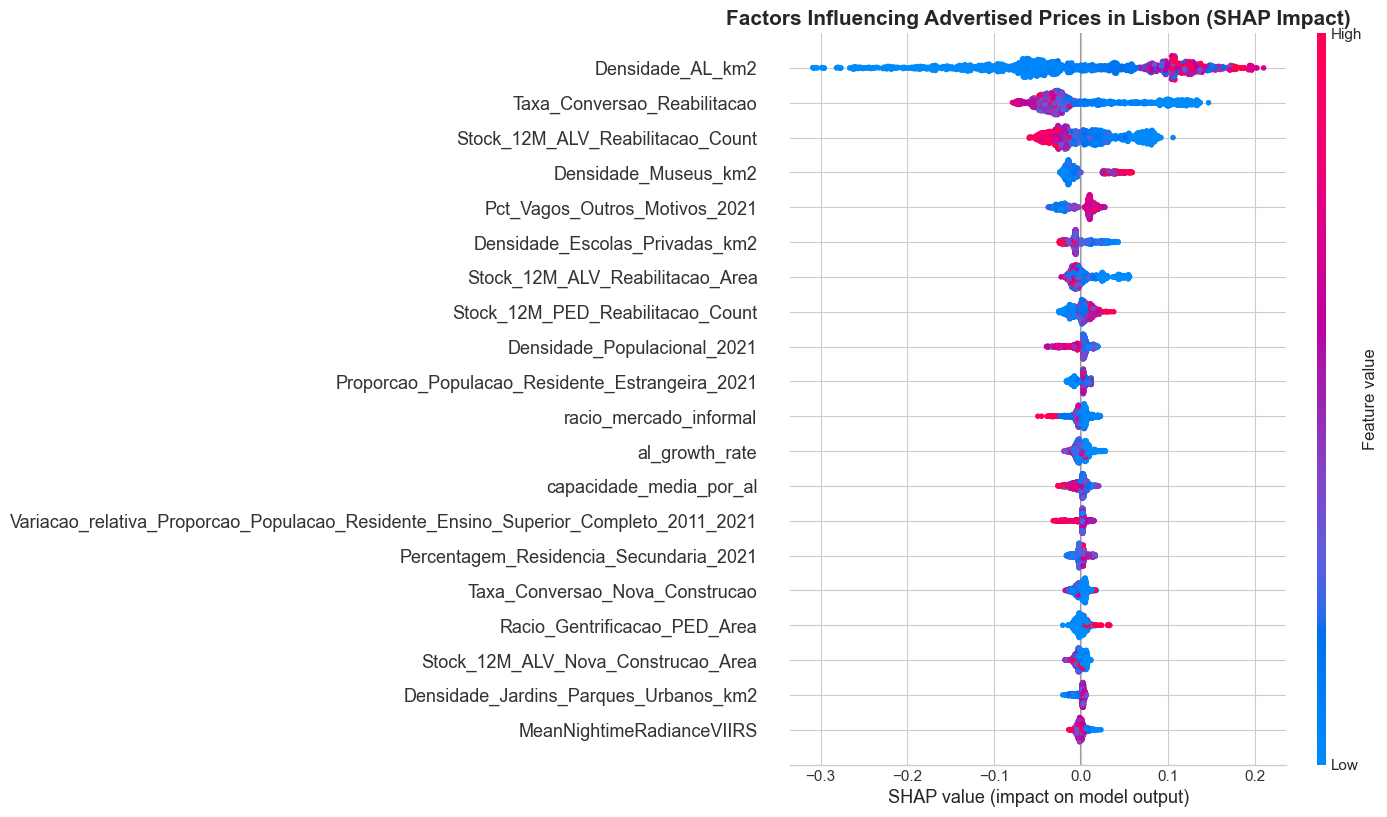

In [67]:
# 1. Calcular SHAP values no Dataset Total
explainer = shap.TreeExplainer(lgbm_final)
shap_values = explainer.shap_values(X_total)

# 2. Summary Plot (Beeswarm)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_total, plot_type="dot", show=False)
plt.title("Factors Influencing Advertised Prices in Lisbon (SHAP Impact)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary_arrendamento.png", dpi=300)
plt.show()

Para interpretar o funcionamento interno do modelo selecionado, foi aplicada a metodologia SHAP (SHapley Additive Explanations), que permite decompor a previsão do modelo e identificar a contribuição marginal de cada variável para a formação do preço estimado.

O SHAP Summary Plot apresenta simultaneamente:
- a importância global das variáveis (ordem vertical)
- a direção do efeito no preço (valores SHAP positivos ou negativos)
- a distribuição dos valores da variável (cores azul → vermelho)

Variáveis no topo do gráfico correspondem às que mais contribuem para explicar a variabilidade do preço imobiliário no modelo.


## ICE Plots

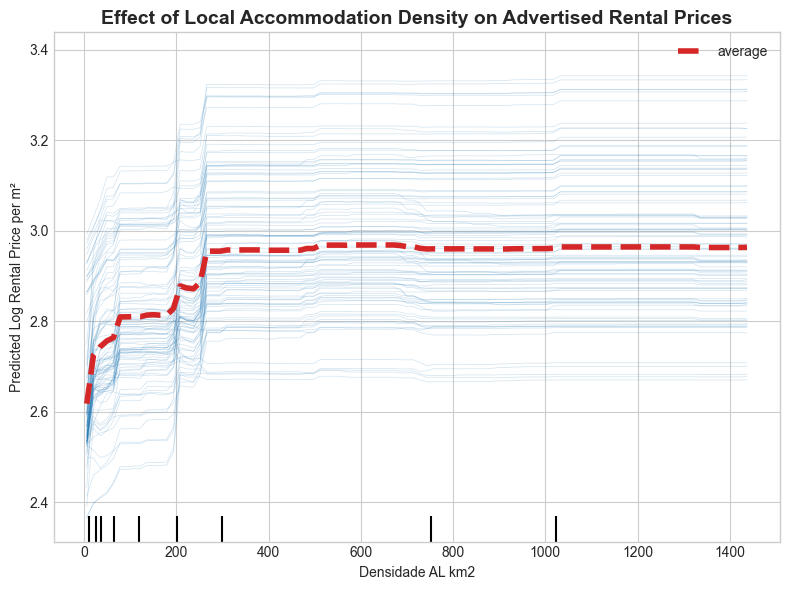

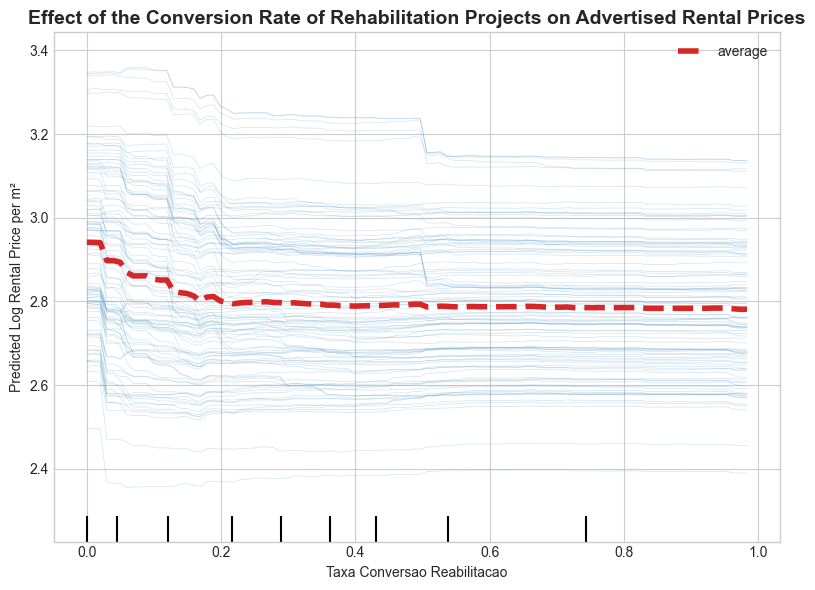

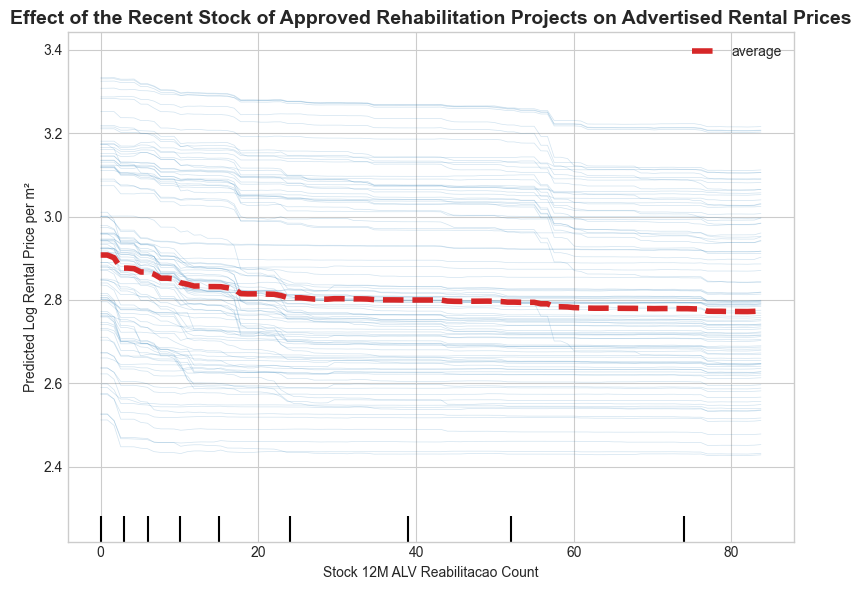

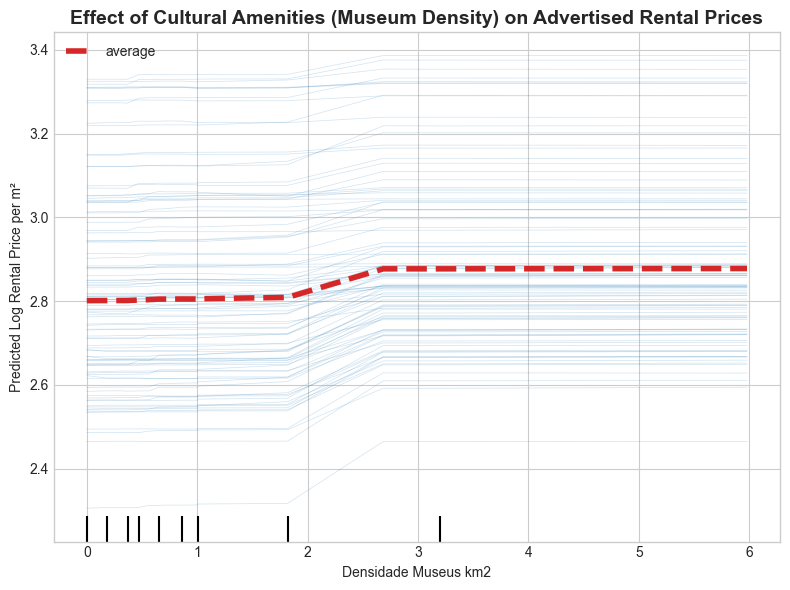

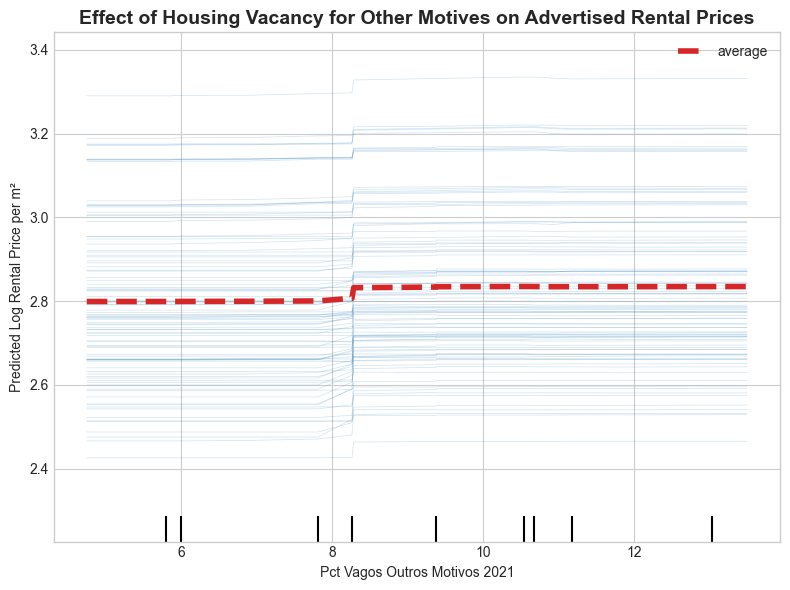

In [68]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_plot = [
    'Densidade_AL_km2',
    'Taxa_Conversao_Reabilitacao',
    'Stock_12M_ALV_Reabilitacao_Count',
    'Densidade_Museus_km2',
    'Pct_Vagos_Outros_Motivos_2021'
]

# Descriptive titles for thesis figures
feature_titles = {
    'Densidade_AL_km2': 'Effect of Local Accommodation Density on Advertised Rental Prices',
    'Taxa_Conversao_Reabilitacao': 'Effect of the Conversion Rate of Rehabilitation Projects on Advertised Rental Prices',
    'Stock_12M_ALV_Reabilitacao_Count': 'Effect of the Recent Stock of Approved Rehabilitation Projects on Advertised Rental Prices',
    'Densidade_Museus_km2': 'Effect of Cultural Amenities (Museum Density) on Advertised Rental Prices',
    'Pct_Vagos_Outros_Motivos_2021': 'Effect of Housing Vacancy for Other Motives on Advertised Rental Prices'
}

for feature in features_to_plot:

    fig, ax = plt.subplots(figsize=(8,6))

    PartialDependenceDisplay.from_estimator(
        lgbm_final,
        X_total,
        features=[feature],
        kind='both',
        subsample=100,
        ice_lines_kw={"color": "tab:blue", "alpha": 0.2, "linewidth": 0.5},
        pd_line_kw={"color": "tab:red", "linewidth": 4},
        ax=ax
    )

    plt.title(feature_titles[feature], fontsize=14, fontweight='bold')
    plt.xlabel(feature.replace("_", " "))
    plt.ylabel("Predicted Log Rental Price per m²")
    
    plt.tight_layout()
    plt.show()

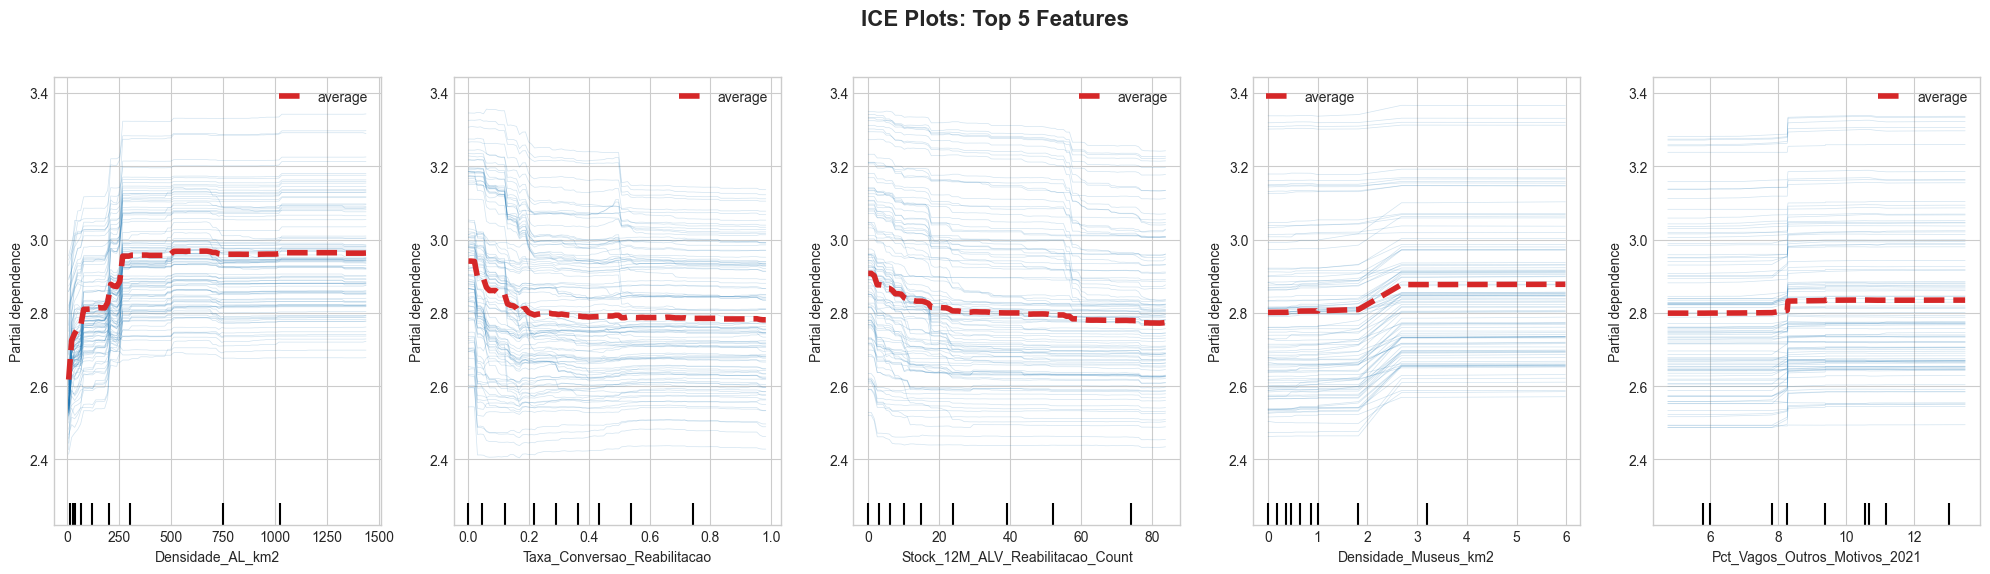

In [69]:
features_to_plot = ['Densidade_AL_km2','Taxa_Conversao_Reabilitacao', 'Stock_12M_ALV_Reabilitacao_Count', 'Densidade_Museus_km2', 'Pct_Vagos_Outros_Motivos_2021', ]

fig, ax = plt.subplots(figsize=(20, 6), ncols=len(features_to_plot))

# Gerar PDP + ICE (kind='both')
# Nota: Como o modelo treinou em log, o eixo Y reflete variação logarítmica
PartialDependenceDisplay.from_estimator(
    lgbm_final, 
    X_total, 
    features=features_to_plot, 
    kind='both',
    subsample=100,
    ice_lines_kw={"color": "tab:blue", "alpha": 0.2, "linewidth": 0.5},
    pd_line_kw={"color": "tab:red", "linewidth": 4},
    ax=ax
)

plt.suptitle("ICE Plots: Top 5 Features", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("ice_plots_lisboa.png", dpi=300)
plt.show()

A interpretação das variáveis explicativas foi realizada através da análise conjunta dos valores SHAP (SHapley Additive Explanations) e dos ICE plots (Individual Conditional Expectation). Enquanto os valores SHAP permitem identificar a importância relativa das variáveis no modelo e o sentido médio do seu impacto sobre o preço anunciado, os ICE plots permitem observar a forma funcional da relação entre cada variável e a variável dependente, revelando possíveis relações não lineares ou efeitos de limiar.

Os resultados sugerem que fatores associados à pressão turística, à disponibilidade efetiva de habitação e à dinâmica de reabilitação urbana desempenham um papel relevante na formação dos preços de arrendamento anunciados na plataforma Idealista.

## Análise
A análise das relações não lineares entre as variáveis explicativas e o preço de arrendamento por metro quadrado anunciado no Idealista permite identificar vários mecanismos relevantes na formação das expectativas dos proprietários no mercado de arrendamento. Os resultados sugerem que fatores associados à pressão turística, à disponibilidade efetiva de habitação e à dinâmica de reabilitação urbana desempenham um papel relevante

**Densidade de Alojamento Local por km²**

Esta variável mede a concentração de unidades de alojamento local numa determinada área geográfica e pode ser interpretada como um indicador da intensidade da atividade turística e da pressão exercida pelo turismo sobre o mercado habitacional local.

A análise do ICE plot revela a existência de um comportamento não linear. Observa-se uma subida acentuada do preço de arrendamento por metro quadrado para valores baixos a moderados da densidade de alojamento local, aproximadamente até cerca de 250 unidades por km². Este padrão sugere a existência de um efeito de sinalização turística: a introdução das primeiras unidades de alojamento local numa zona altera rapidamente as expectativas dos proprietários relativamente ao potencial de valorização do mercado.

Na prática, quando uma área começa a registar atividade relevante de alojamento local, os proprietários podem passar a considerar que o valor económico da localização está a aumentar devido à procura associada ao turismo. Mesmo quando os imóveis não são destinados diretamente ao mercado turístico, a perceção de maior valorização territorial pode levar os proprietários a ajustar em alta os preços anunciados de arrendamento.

Contudo, após atingir determinados níveis de densidade, a relação entre a presença de alojamento local e o preço anunciado tende a estabilizar. Este comportamento sugere um efeito de saturação, no qual o impacto marginal de unidades adicionais de alojamento local diminui. Nestas circunstâncias, a área já é percecionada como uma zona fortemente turística e as expectativas de valorização associadas a essa dinâmica encontram-se já refletidas nos preços anunciados.

Este resultado é consistente com a literatura que identifica a atividade turística como um fator de pressão sobre os mercados locais de habitação, particularmente em centros urbanos com elevada atratividade turística.

**Taxa de Conversão de Projetos de Reabilitação**

A variável corresponde à razão entre a área de projetos de reabilitação aprovados (alvarás emitidos) e a área total de projetos submetidos para aprovação. Esta variável pode ser interpretada como um indicador da eficiência do processo de transformação urbanística e da probabilidade de que projetos planeados se concretizem efetivamente.

Os resultados do ICE plot sugerem que, à medida que esta taxa aumenta, o impacto sobre o preço anunciado tende a diminuir ligeiramente e posteriormente estabiliza. Este comportamento pode refletir a diferença entre expectativas de transformação urbana e transformação efetiva do stock habitacional.

Quando existem muitos projetos de reabilitação submetidos mas poucos efetivamente aprovados ou concluídos, pode surgir uma dinâmica de valorização baseada sobretudo em expectativas. A perceção de que uma determinada área poderá sofrer um processo de reabilitação urbana no futuro pode levar proprietários e investidores a antecipar uma valorização futura da área, refletindo essas expectativas nos preços anunciados.

Por outro lado, quando a taxa de conversão é elevada, os projetos de reabilitação tendem a materializar-se com maior frequência, resultando na introdução efetiva de habitações renovadas no mercado. Este aumento da oferta potencial pode contribuir para moderar a pressão especulativa associada apenas a expectativas de valorização futura, conduzindo a uma maior estabilidade nos preços anunciados.

**Stock Recente de Projetos de Reabilitação Aprovados**

A variável Stock_12M_ALV_Reabilitacao_Count representa o número de projetos de reabilitação aprovados nos últimos doze meses. Trata-se de um indicador da intensidade recente da atividade de renovação urbana numa determinada área.

A análise revela uma tendência ligeiramente descendente na relação entre esta variável e o preço anunciado de arrendamento por metro quadrado. Este resultado sugere que um maior volume de projetos de reabilitação aprovados pode estar associado a uma moderação das expectativas de preço no mercado.

Uma possível explicação para este padrão reside no facto de um elevado número de projetos aprovados sinalizar um aumento potencial da oferta habitacional no médio prazo. Mesmo que as unidades resultantes desses projetos ainda não estejam disponíveis para arrendamento, a antecipação da sua entrada no mercado pode reduzir a pressão especulativa sobre o stock habitacional existente.

Além disso, a reabilitação urbana tende frequentemente a substituir edifícios degradados por unidades habitacionais renovadas, o que pode contribuir para uma reestruturação do mercado local. Este processo pode reduzir a valorização especulativa de imóveis em estado degradado que anteriormente poderiam ser objeto de expectativas de reabilitação futura.

**Densidade de Museus por km²**

A variável Densidade_Museus_km2 representa o número de museus por quilómetro quadrado numa determinada área geográfica e pode ser interpretada como um indicador da intensidade de equipamentos culturais e da centralidade urbana associada à atividade cultural e turística.

Os valores SHAP indicam que níveis mais elevados de densidade de museus estão, em média, associados a contribuições positivas para o valor previsto do preço de arrendamento.

A análise dos ICE plots permite compreender de forma mais detalhada a forma funcional desta relação. Observa-se um comportamento ligeiramente crescente, com um aumento inicial do preço anunciado à medida que a densidade de museus aumenta a partir de níveis muito baixos. Este crescimento ocorre sobretudo nos primeiros intervalos da variável, após o qual a curva tende a estabilizar, indicando que o impacto marginal de novos equipamentos culturais diminui para níveis mais elevados de densidade.

Este padrão pode ser interpretado à luz da literatura sobre amenidades urbanas e valorização imobiliária. A presença de equipamentos culturais, como museus, contribui frequentemente para reforçar a atratividade de determinadas áreas urbanas, sinalizando níveis elevados de centralidade, oferta cultural e potencial turístico. Estas características podem aumentar a procura residencial, particularmente em zonas históricas ou centrais da cidade.

Contudo, o comportamento de estabilização observado no ICE plot sugere que este efeito é mais relevante nas fases iniciais de concentração cultural. Ou seja, a introdução ou presença de alguns equipamentos culturais numa determinada área pode alterar significativamente a perceção de qualidade urbana e atratividade da localização. Após atingir determinados níveis de densidade, o impacto marginal de museus adicionais tende a reduzir-se, uma vez que a área já é percecionada como um polo cultural consolidado.

Assim, esta variável pode ser interpretada como um indicador indireto de amenidades urbanas e centralidade cultural, cuja presença parece contribuir positivamente para a formação dos preços anunciados de arrendamento, sobretudo em áreas onde a oferta cultural ainda não atingiu níveis elevados de concentração.

**Percentagem de Habitações Vagas por Outros Motivos (exclui Arrendamento, venda ou processos de obra ou demolição)**

A variável Pct_Vagos_Outros_Motivos_2021 representa a percentagem de habitações classificadas como vagas por “outros motivos” nos Censos 2021, produzidos pelo Instituto Nacional de Estatística, relativamente ao total de alojamentos existentes em cada unidade territorial. Esta categoria exclui explicitamente habitações vagas associadas a processos diretamente relacionados com o funcionamento do mercado habitacional, tais como habitações vagas para venda, para arrendamento, ou temporariamente desocupadas devido à realização de obras, demolição ou outras intervenções estruturais

Assim, esta variável capta situações em que os alojamentos permanecem desocupados sem uma finalidade de transação ou intervenção estrutural claramente identificada. A categoria “outros motivos” constitui uma classificação residual nos dados censitários e pode incluir diferentes tipos de situações, como habitações temporariamente não utilizadas, imóveis associados a processos sucessórios ou administrativos, habitações pertencentes a proprietários institucionais ou entidades públicas, bem como outros casos em que o imóvel se encontra desocupado sem uma utilização imediata definida.

Importa salientar que esta variável não permite identificar diretamente as motivações específicas dos proprietários para manter os imóveis desocupados, nem distinguir entre diferentes tipos de propriedade, como propriedade privada, institucional ou pública. No entanto, níveis elevados deste tipo de vacância podem refletir situações em que uma parte do parque habitacional permanece fora do mercado habitacional ativo, não estando disponível para arrendamento ou venda no curto prazo.

Do ponto de vista económico, este fenómeno pode ser interpretado como uma forma de oferta habitacional não mobilizada, que reduz a quantidade de habitações efetivamente disponíveis no mercado. Mesmo quando o stock total de habitação existente numa determinada área permanece constante, a existência de uma proporção significativa de imóveis desocupados pode limitar a oferta acessível aos potenciais arrendatários.

A análise da relação entre esta variável e o preço de arrendamento por metro quadrado anunciado na plataforma Idealista revela um comportamento não linear, caracterizado por um padrão próximo de um “degrau”. Para níveis relativamente baixos de habitações vagas por outros motivos — aproximadamente até cerca de 8-9% do parque habitacional — o preço anunciado apresenta variações relativamente reduzidas. Contudo, a partir desse limiar observa-se um aumento no nível médio dos preços anunciados, que posteriormente tende a estabilizar.

Este padrão pode ser interpretado como um possível efeito associado à redução da oferta efetivamente disponível no mercado de arrendamento. Quando uma proporção relevante do parque habitacional permanece desocupada e fora do mercado, a quantidade de habitações acessíveis aos arrendatários diminui, o que pode gerar uma perceção de maior escassez no mercado local. Esta perceção pode influenciar as expectativas dos proprietários relativamente ao valor potencial dos seus imóveis.

No contexto de plataformas de anúncios imobiliários como o Idealista, onde os preços refletem sobretudo as expectativas e estratégias de fixação de preços dos proprietários, uma menor disponibilidade aparente de habitações pode incentivar os anunciantes a manter ou aumentar os valores pedidos. Desta forma, áreas com maior proporção de habitações vagas por outros motivos podem apresentar níveis mais elevados de preços anunciados, mesmo que o stock total de habitação existente não se altere.

Em síntese, esta variável deve ser interpretada como um indicador indireto da proporção de habitação que não se encontra mobilizada no mercado, podendo influenciar as expetativas de preço no mercado de arrendamento através do seu efeito potencial sobre a oferta efetiva de habitação disponível.

**Considerações sobre o Preço Anunciado**

É importante salientar que a variável dependente utilizada nesta análise corresponde ao preço de arrendamento anunciado por metro quadrado na plataforma Idealista, e não necessariamente ao preço efetivamente transacionado no mercado.

Por esta razão, os resultados devem ser interpretados sobretudo como indicadores dos fatores que influenciam as expectativas e estratégias de fixação de preços por parte dos proprietários e anunciantes. Variáveis associadas à pressão turística, à perceção de escassez habitacional e às expectativas de transformação urbana podem ter um impacto particularmente relevante neste contexto, uma vez que influenciam diretamente a forma como os proprietários avaliam o potencial económico das suas propriedades ao definir o preço anunciado.

In [108]:
import json
import re

In [102]:
import joblib

# 1. Guardar o Cérebro (O Modelo Treinado)
# Isto vai criar o ficheiro .pkl na mesma pasta onde está o teu Notebook
joblib.dump(lgbm_final, 'augmented_lightgbm_model.pkl')

# 2. Guardar a Memória (Os Dados de Teste para o Simulador)
# Isto garante que o dashboard tem os dados base para simular (como o caso dos 47 ALs)
X_test_aug.to_pickle('X_test_aug.pkl')

# 3. Guardar o dicionário tradutor (Para os nomes aparecerem bonitos no Streamlit)
joblib.dump(dicionario_freguesias, 'dicionario_freguesias.pkl')

print("✅ Modelo e Dados guardados com sucesso!")
print("Já podes fechar o Jupyter e abrir o Streamlit para a apresentação. 🚀")

✅ Modelo e Dados guardados com sucesso!
Já podes fechar o Jupyter e abrir o Streamlit para a apresentação. 🚀


In [ ]:
# import warnings
# warnings.filterwarnings('ignore') # Para não assustar os chefes com avisos vermelhos no ecrã

# def simulador_politicas_urbanas(modelo, X_dados, indice_freguesia, variavel, novo_valor):
#     """
#     Simula o impacto de uma alteração de política numa freguesia específica.
#     """
#     # 1. Isolar a observação atual (ex: Arroios no mês mais recente)
#     # Nota: substitui 'indice_freguesia' pelo index da linha que queres testar no X_test_aug
#     observacao_atual = X_dados.loc[[indice_freguesia]].copy()
    
#     # 2. Previsão Base (Cenário Real)
#     pred_log_base = modelo.predict(observacao_atual)
#     preco_base = np.expm1(pred_log_base)[0] # Usar expm1 tal como no teu código
#     valor_antigo_feature = observacao_atual[variavel].values[0]
    
#     # 3. Alterar a Variável (A Simulação Política)
#     observacao_simulada = observacao_atual.copy()
#     observacao_simulada[variavel] = novo_valor
    
#     # 4. Previsão Simulada (Cenário "What-If")
#     pred_log_simulada = modelo.predict(observacao_simulada)
#     preco_simulado = np.expm1(pred_log_simulada)[0]
    
#     # 5. Cálculo do Impacto
#     impacto_abs = preco_simulado - preco_base
#     impacto_pct = (impacto_abs / preco_base) * 100
    
#     # 6. O "Show" para os Chefes
#     print("\n" + "="*50)
#     print(f"🏢 AUDITORIA DE IMPACTO URBANÍSTICO")
#     print("="*50)
#     print(f"Variável alterada: {variavel}")
#     print(f"Cenário Anterior:  {valor_antigo_feature:.2f}  ->  Preço: {preco_base:.2f} €/m²")
#     print(f"Cenário Simulado:  {novo_valor:.2f}  ->  Preço: {preco_simulado:.2f} €/m²")
#     print("-" * 50)
    
#     if impacto_pct > 0:
#         print(f"📈 IMPACTO ESPERADO: Aumento de {impacto_abs:.2f} €/m² (+{impacto_pct:.2f}%)")
#     else:
#         print(f"📉 IMPACTO ESPERADO: Redução de {abs(impacto_abs):.2f} €/m² ({impacto_pct:.2f}%)")
#     print("="*50 + "\n")

# # ==========================================
# # COMO EXECUTAR NA REUNIÃO (O TEU "BOTÃO MÁGICO")
# # ==========================================

# # Exemplo: Simular a suspensão total de Alojamento Local numa freguesia
# # (Substitui o 'idx_arroios' pelo index real da linha de Arroios no teu dataset de teste)

# idx_arroios = X_test_aug.index[0] # Altera para o index correto da tua dataframe

# # Simulação: Reduzir a Densidade_AL_km2 para 0
# simulador_politicas_urbanas(
#     modelo=lgbm_final, 
#     X_dados=X_test_aug, 
#     indice_freguesia=idx_arroios, 
#     variavel='Densidade_AL_km2', # A variável dominante segundo a tua tese
#     novo_valor=0.0 
# )


🏢 AUDITORIA DE IMPACTO URBANÍSTICO
Variável alterada: Densidade_AL_km2
Cenário Anterior:  47.00  ->  Preço: 19.05 €/m²
Cenário Simulado:  0.00  ->  Preço: 16.25 €/m²
--------------------------------------------------
📉 IMPACTO ESPERADO: Redução de 2.79 €/m² (-14.65%)



In [116]:
import geopandas as gpd

# 1. Ler o ficheiro GPKG (Pode demorar uns segundos porque é o país todo)
# Nota: Verifica se o nome do ficheiro está exatamente igual ao que tens na pasta
caminho_gpkg = 'Continente_CAOP2025.gpkg'
gdf = gpd.read_file(caminho_gpkg)

# 2. Filtrar apenas LISBOA (usando a coluna exata 'municipio')
lisboa_gdf = gdf[gdf['municipio'].str.upper() == 'LISBOA'].copy()

# 3. Limpar os nomes burocráticos
def limpar_nome(nome):
    # Corta as palavras iniciais que não interessam
    nome = re.sub(r"^(União das Freguesias de |Freguesia de )", "", str(nome))
    return nome.strip()

# Criamos uma nova coluna chamada 'Freguesia' (com 'F' maiúsculo) 
# para bater 100% certo com o código que já tens no Dashboard
lisboa_gdf['Freguesia'] = lisboa_gdf['freguesia'].apply(limpar_nome)

# 4. Converter as coordenadas para o formato web do Folium (WGS84)
lisboa_gdf = lisboa_gdf.to_crs(epsg=4326)

# 5. Guardar o ficheiro de Ouro (só com o que interessa para ficar leve)
lisboa_limpo = lisboa_gdf[['Freguesia', 'geometry']]
lisboa_limpo.to_file("lisboa_poligonos_caop.geojson", driver='GeoJSON')

print(f"✅ BINGO! Extraídas {len(lisboa_limpo)} freguesias perfeitas.")
print("Ficheiro 'lisboa_poligonos_caop.geojson' criado com sucesso!")

c:\Users\migue\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'Continente_CAOP2025.gpkg': 'cont_areas_administrativas' (default), 'cont_distritos', 'cont_freguesias', 'cont_municipios', 'cont_nuts1', 'cont_nuts2', 'cont_nuts3', 'cont_trocos', 'layer_styles', 'inf_fonte_troco'. Specify layer parameter to avoid this warning.
  result = read_func(


✅ BINGO! Extraídas 24 freguesias perfeitas.
Ficheiro 'lisboa_poligonos_caop.geojson' criado com sucesso!
